# QuickCommerce Analytics & Profit Optimization Engine

# Data Ingestion

In [1]:
import pandas as pd
import numpy as np
import json
import xml.etree.ElementTree as ET # For XML parsing
from pathlib import Path # For file path handling
import re # For regex operations

In [2]:
RAW_PATH = Path(r"D:\Personal\Data Science\Data Science\Revision\End to End Project\Python_1")

orders_path = RAW_PATH / "orders_raw.txt"
users_path = RAW_PATH / "users_raw.xlsx"
products_path = RAW_PATH / "products_raw.csv"
items_path = RAW_PATH / "order_items_raw.json"
stores_path = RAW_PATH / "stores_raw.xml"

In [3]:
#loading the orders_raw file, but it is a txt file, so we need to specify the separator and the engine to read it correctly. The separator is a pipe (|) and the engine is python.

with open(orders_path, "r") as f:
    for _ in range(5):
        print(f.readline())


order_id | user_id | order_date | city | store_id | delivery_time_min | order_status | payment_type

10001 | U0254 | 03-01-2024 08:47 | Hyderabad | S05 |  | Delivered | UPI

10002 | U0851 | 2024-01-05 16:46:00 | Mumbai | S18 | 48 | Delivered | Card

10003 | U0640 | 07-02-2024 12:12 | Hyderabad | S17 | 57 | Cancelled | COD

10004 | U0542 | 2024/01/30 06:06:00 | Chennai | S16 |  | Cancelled | UPI



In [4]:
orders = pd.read_csv( 
    orders_path, # but the orders path was a txt file, si how come read_csv is working? because the data is separated by a delimiter, in this case, a pipe (|), so we can use read_csv with the appropriate separator to read the data correctly.
    sep="|",
    engine="python"
)


In [5]:
orders.columns = orders.columns.str.strip() # Strip whitespace from column names
orders = orders.applymap(lambda x: x.strip() if isinstance(x, str) else x) # Strip whitespace from column names and values, what is isinstance? isinstance is a built-in function in Python that checks if an object is an instance of a specified type or class. In this case, it checks if x is a string (str) before applying the strip() method to remove leading and trailing whitespace. If x is not a string, it returns x unchanged.


# how is applymap different from map? applymap is for DataFrames and applies a function to every element, while map is for Series and a
# applies a function to each element in the Series.
# but then orders is a DataFrame, so we should use applymap instead of map to strip whitespace from all values in the DataFrame. The correct code would be: 



C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\2794135962.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  orders = orders.applymap(lambda x: x.strip() if isinstance(x, str) else x) # Strip whitespace from column names and values, what is isinstance? isinstance is a built-in function in Python that checks if an object is an instance of a specified type or class. In this case, it checks if x is a string (str) before applying the strip() method to remove leading and trailing whitespace. If x is not a string, it returns x unchanged.


In [6]:
print(orders.shape)
print(orders.dtypes)
print(orders.isnull().sum())
print(orders.duplicated().sum())


(1500, 8)
order_id              int64
user_id              object
order_date           object
city                 object
store_id             object
delivery_time_min    object
order_status         object
payment_type         object
dtype: object
order_id             0
user_id              0
order_date           0
city                 0
store_id             0
delivery_time_min    0
order_status         0
payment_type         0
dtype: int64
0


In [7]:
orders.head()

,order_id,user_id,order_date,city,store_id,delivery_time_min,order_status,payment_type
0,10001,U0254,03-01-2024 08:47,Hyderabad,S05,,Delivered,UPI
1,10002,U0851,2024-01-05 16:46:00,Mumbai,S18,48,Delivered,Card
2,10003,U0640,07-02-2024 12:12,Hyderabad,S17,57,Cancelled,COD
3,10004,U0542,2024/01/30 06:06:00,Chennai,S16,,Cancelled,UPI
4,10005,U0571,15-01-2024 13:35,Bangalore,S18,42,Cancelled,UPI


In [8]:
# Ingest order_items table, but it is a json file, so we need to use the json module to read it correctly. The json module provides a method called load() that can be used to read a json file and convert it into a Python dictionary. We can then convert the dictionary into a DataFrame using the pd.DataFrame() constructor.
# now load the order_items_raw.json file, but it is a json file, so we need to use the json module to read it correctly. 
# The json module provides a method called load() that can be used to read a json file and convert it into a Python dictionary. 
# We can then convert the dictionary into a DataFrame using the pd.DataFrame() constructor.


with open(items_path, "r") as f:
    items_data = json.load(f)

In [9]:
# check the structure of the items_data dictionary to understand how to convert it into a DataFrame. We can use the keys() method to see the top-level keys in the dictionary.


print(len(items_data)) # check the number of records in the items_data dictionary
print(type(items_data)) # check the type of items_data, it should be a list of dictionaries
items_data[0] # check the first record in the items_data list to see the structure of the data


1500
<class 'list'>


{'order_id': 10001,
 'items': [{'product_id': 'P0352', 'qty': 4, 'price': '211.0', 'discount': 0}]}

In [10]:
# normalize the items_data list of dictionaries into a DataFrame using pd.json_normalize() function, which is designed to handle nested JSON data and convert it into a flat table format. This function will help us to create a DataFrame where each key in the dictionaries becomes a column and the values become the corresponding entries in the DataFrame.

items_df = pd.json_normalize(items_data,record_path=['items'], meta=['order_id'])

#what is record_path and meta in pd.json_normalize? record_path is the path to the list of records we want to normalize, in this case, it is the 'items' key in the dictionaries. meta is a list of keys that we want to include as metadata in the resulting DataFrame, in this case, it is the 'order_id' key from the parent dictionary.

In [11]:
items_df.head()


,product_id,qty,price,discount,order_id
0,P0352,4,211.0,0.0,10001
1,P0059,3,67.0,NaN,10002
2,P0163,2,441,NaN,10002
3,P0149,1,24.0,0.0,10002
4,P0334,4,273.0,NaN,10003


In [12]:
# validate the structure

items_df.info()

items_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4515 entries, 0 to 4514
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   product_id  4515 non-null   object 
 1   qty         4515 non-null   int64  
 2   price       4515 non-null   object 
 3   discount    3044 non-null   float64
 4   order_id    4515 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 176.5+ KB


np.int64(0)

In [13]:
items_df.isnull().sum()

product_id       0
qty              0
price            0
discount      1471
order_id         0
dtype: int64

In [14]:
# Do all order_ids exist in orders?

set(items_df["order_id"]) - set(orders["order_id"]) # check if there are any order_ids in items_df that are not in orders, we need to convert the order_id in orders to int because it is currently a string due to the whitespace we stripped earlier.


set()

In [15]:
# Ingest Users Excel

users = pd.read_excel(users_path)


In [16]:
users["signup_date"].isna().sum() # now all the dates should be parsed correctly and there should be no missing values in the signup_date column. We can verify this by checking the number of missing values again, which should return 0. This means that all the dates have been successfully converted to datetime format and are ready for analysis.

np.int64(0)

In [17]:
users.head()


,user_id,signup_date,city,referral_code,is_premium,age
0,U0001,2023-11-24,Mumbai,NaN,No,26.0
1,U0002,2023/12/13,Chennai,REF21,Yes,19.0
2,U0003,2023-04-22,Chennai,NaN,No,NaN
3,U0004,23/04/2023,Chennai,NaN,No,NaN
4,U0005,2023-05-23,Delhi,NaN,Yes,42.0


In [18]:
users.dtypes


user_id           object
signup_date       object
city              object
referral_code     object
is_premium        object
age              float64
dtype: object

In [19]:
users["user_id"].nunique()



1200

In [20]:
users.duplicated("user_id").sum()


np.int64(0)

In [436]:
# 🔹 STEP 6 — Ingest Products (Messy CSV)

products = pd.read_csv(products_path)
products.head()

,product_id,category,subcategory,brand,mrp,cost_price
0,P0001,Beverages,SubB,NaN,₹461,406.64
1,P0002,Beverages,SubB,NaN,₹400,316.93
2,P0003,Grocery,SubB,BrandX,321,229.66
3,P0004,Snacks,SubA,NaN,₹309,256.90
4,P0005,Beverages,SubC,NaN,₹404,326.81


In [437]:
products["mrp"].unique()[:10]


array(['₹461', '₹400', '321', '₹309', '₹404', '353', '491', '253', '₹414',
       '₹481'], dtype=object)

In [23]:
# 🔹 STEP 7 — Ingest Stores (XML)

tree = ET.parse(stores_path)
root = tree.getroot()

In [24]:
stores_list = []


for store in root:
    stores_list.append({
        "store_id": store.find("store_id").text,
        "city": store.find("city").text,
        "store_size_sqft": store.find("store_size_sqft").text,
        "opening_date": store.find("opening_date").text
    })

stores = pd.DataFrame(stores_list)


In [25]:
stores.head()

,store_id,city,store_size_sqft,opening_date
0,S01,Hyderabad,1474,15-03-2023
1,S02,Mumbai,2423,2023-12-13
2,S03,Hyderabad,4441,20-08-2023
3,S04,Delhi,1118,2023-05-09
4,S05,Hyderabad,1249,25-09-2023


In [26]:
stores.store_id.nunique()

20

In [27]:
stores.dtypes


store_id           object
city               object
store_size_sqft    object
opening_date       object
dtype: object

In [28]:
stores.isnull().sum()

store_id           0
city               0
store_size_sqft    0
opening_date       0
dtype: int64

In [29]:
set(orders["user_id"]) - set(users["user_id"])


set()

In [30]:
set(orders["store_id"]) - set(stores["store_id"])


set()

In [31]:
set(items_df["product_id"]) - set(products["product_id"])

# We have successfully ingested all the raw data files and performed initial validation checks to ensure data integrity. The next steps will involve cleaning and transforming the data to prepare it for analysis.



set()

In [32]:
print("Orders:", orders.shape)
print("Users:", users.shape)
print("Products:", products.shape)
print("Order Items:", items_df.shape)
print("Stores:", stores.shape)


Orders: (1500, 8)
Users: (1200, 6)
Products: (500, 6)
Order Items: (4515, 5)
Stores: (20, 4)


# DATA CLEANING

In [33]:
orders.columns = orders.columns.str.strip().str.lower() 
orders = orders.applymap(lambda x: x.strip() if isinstance(x, str) else x)



C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\3264734967.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  orders = orders.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [34]:
orders.dtypes

order_id              int64
user_id              object
order_date           object
city                 object
store_id             object
delivery_time_min    object
order_status         object
payment_type         object
dtype: object

In [35]:
orders.head(10)

,order_id,user_id,order_date,city,store_id,delivery_time_min,order_status,payment_type
0,10001,U0254,03-01-2024 08:47,Hyderabad,S05,,Delivered,UPI
1,10002,U0851,2024-01-05 16:46:00,Mumbai,S18,48,Delivered,Card
2,10003,U0640,07-02-2024 12:12,Hyderabad,S17,57,Cancelled,COD
3,10004,U0542,2024/01/30 06:06:00,Chennai,S16,,Cancelled,UPI
4,10005,U0571,15-01-2024 13:35,Bangalore,S18,42,Cancelled,UPI
5,10006,U0764,2024/02/01 23:25:00,Mumbai,S15,24,Cancelled,UPI
6,10007,U1154,2024-01-29 11:30:00,Bangalore,S11,19,Delivered,Card
7,10008,U1004,2024/01/11 06:55:00,Delhi,S03,,Returned,COD
8,10009,U1161,2024-02-03 23:53:00,Mumbai,S16,,Cancelled,Card
9,10010,U0659,2024/01/22 04:02:00,Chennai,S20,36,Cancelled,Card


In [36]:
orders["order_id"] = orders["order_id"].astype(int)
orders["delivery_time_min"] = pd.to_numeric(orders["delivery_time_min"], errors="coerce") # error="coerce" will convert any non-numeric values to NaN, which can be handled later during data cleaning and analysis. 
# This is useful for ensuring that the delivery_time_min column contains only numeric values, allowing for accurate calculations and analysis of delivery times.



In [37]:
orders.head()

,order_id,user_id,order_date,city,store_id,delivery_time_min,order_status,payment_type
0,10001,U0254,03-01-2024 08:47,Hyderabad,S05,NaN,Delivered,UPI
1,10002,U0851,2024-01-05 16:46:00,Mumbai,S18,48.0,Delivered,Card
2,10003,U0640,07-02-2024 12:12,Hyderabad,S17,57.0,Cancelled,COD
3,10004,U0542,2024/01/30 06:06:00,Chennai,S16,NaN,Cancelled,UPI
4,10005,U0571,15-01-2024 13:35,Bangalore,S18,42.0,Cancelled,UPI


In [96]:
orders["order_date"].dtype


dtype('O')

In [ ]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce",
    dayfirst=True
)  # this is not parsing correctly because the date format is not consistent, some are in dd/mm/yyyy and some are in mm/dd/yyyy, so we need to specify dayfirst=True to tell pandas to interpret the first part of the date as the day. This will help to parse the dates correctly and avoid any confusion between day and month.

In [ ]:
orders["order_date"].isna().sum() # still 1006 missing values in order_date, we can investigate further to see if there are any patterns in the missing data or if there are any specific records that are causing the issue. We can also consider using other methods to handle the missing values, such as imputation or dropping the records with missing order_date, depending on the context of our analysis and the importance of the order_date variable.


np.int64(1006)

In [ ]:
raw_orders = pd.read_csv(orders_path, sep="|")
raw_orders.columns = raw_orders.columns.str.strip()

bad_dates = raw_orders.loc[
    pd.to_datetime(raw_orders["order_date"], errors="coerce").isna(),
    "order_date"
]

bad_dates.head(20) # these are the bad dates that could not be converted to datetime format, 
#we can see that they are in different formats and some of them are invalid dates. We will need to clean these dates before we can use them for analysis.



1      2024-01-05 16:46:00 
3      2024/01/30 06:06:00 
4         15-01-2024 13:35 
5      2024/02/01 23:25:00 
6      2024-01-29 11:30:00 
7      2024/01/11 06:55:00 
8      2024-02-03 23:53:00 
9      2024/01/22 04:02:00 
10     2024/01/14 17:50:00 
11     2024/02/15 15:32:00 
12     2024/02/18 00:10:00 
13     2024/02/26 13:31:00 
14     2024/01/19 03:27:00 
15     2024/01/11 04:18:00 
16        17-01-2024 15:29 
17     2024-01-27 05:09:00 
18     2024-01-07 17:29:00 
20        16-02-2024 09:23 
23     2024-02-12 15:13:00 
24     2024-01-31 00:20:00 
Name: order_date, dtype: object

In [38]:
from datetime import datetime

def parse_mixed(date):
    for fmt in [
        "%d-%m-%Y %H:%M",
        "%Y-%m-%d %H:%M:%S",
        "%Y/%m/%d %H:%M:%S"
    ]:
        try:
            return datetime.strptime(date, fmt)
        except:
            continue
    return pd.NaT

orders["order_date"] = orders["order_date"].apply(parse_mixed)

In [39]:
orders["order_date"].isna().sum()  
# now all the dates should be parsed correctly and there should be no missing values in the order_date column. 
# We can verify this by checking the number of missing values again, which should return 0. This means that all the dates have been successfully converted to datetime format and are ready for analysis.

np.int64(0)

In [40]:
orders["order_year"] = orders["order_date"].dt.year
orders["order_month"] = orders["order_date"].dt.month
orders["order_day"] = orders["order_date"].dt.day
orders["order_hour"] = orders["order_date"].dt.hour
orders["order_week"] = orders["order_date"].dt.isocalendar().week


In [41]:
orders.head()

,order_id,user_id,order_date,city,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,order_day,order_hour,order_week
0,10001,U0254,2024-01-03 08:47:00,Hyderabad,S05,NaN,Delivered,UPI,2024,1,3,8,1
1,10002,U0851,2024-01-05 16:46:00,Mumbai,S18,48.0,Delivered,Card,2024,1,5,16,1
2,10003,U0640,2024-02-07 12:12:00,Hyderabad,S17,57.0,Cancelled,COD,2024,2,7,12,6
3,10004,U0542,2024-01-30 06:06:00,Chennai,S16,NaN,Cancelled,UPI,2024,1,30,6,5
4,10005,U0571,2024-01-15 13:35:00,Bangalore,S18,42.0,Cancelled,UPI,2024,1,15,13,3


In [42]:
orders.dtypes

order_id                      int64
user_id                      object
order_date           datetime64[ns]
city                         object
store_id                     object
delivery_time_min           float64
order_status                 object
payment_type                 object
order_year                    int32
order_month                   int32
order_day                     int32
order_hour                    int32
order_week                   UInt32
dtype: object

In [43]:
orders['order_status'].unique()

array(['Delivered', 'Cancelled', 'Returned'], dtype=object)

In [44]:
orders['payment_type'].unique()

array(['UPI', 'Card', 'COD'], dtype=object)

In [45]:
orders['city'].unique()

array(['Hyderabad', 'Mumbai', 'Chennai', 'Bangalore', 'Delhi'],
      dtype=object)

In [46]:
orders["order_status"].value_counts()


order_status
Cancelled    524
Delivered    507
Returned     469
Name: count, dtype: int64

In [47]:
# Step 6 — Handle Missing Delivery Times
# flagging those accounts jaha order is deleivered but delivery time is missing, this could be a data entry error or a system issue that caused the delivery time to not be recorded. We can create a new column called "delivery_time_missing" and set it to True for those records where the order_status is "delivered" but the delivery_time_min is null. This will allow us to easily identify and analyze these cases separately from the rest of the data.
orders["delivery_time_missing"] = (orders["order_status"] == "Delivered") & (orders["delivery_time_min"].isnull())

In [48]:
orders.head(2)

,order_id,user_id,order_date,city,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,order_day,order_hour,order_week,delivery_time_missing
0,10001,U0254,2024-01-03 08:47:00,Hyderabad,S05,NaN,Delivered,UPI,2024,1,3,8,1,True
1,10002,U0851,2024-01-05 16:46:00,Mumbai,S18,48.0,Delivered,Card,2024,1,5,16,1,False


In [49]:
orders.dtypes 

# all looks good, we have successfully cleaned and transformed the orders data, and we are now ready to move on to the next steps of our analysis. We can now explore the data further, perform any additional cleaning if necessary, and start deriving insights from the orders dataset.

order_id                          int64
user_id                          object
order_date               datetime64[ns]
city                             object
store_id                         object
delivery_time_min               float64
order_status                     object
payment_type                     object
order_year                        int32
order_month                       int32
order_day                         int32
order_hour                        int32
order_week                       UInt32
delivery_time_missing              bool
dtype: object

In [111]:
# order items cleaning and transformation will be done in the next steps, but we have successfully cleaned and transformed the orders dataset, 

items_df.head()

,product_id,qty,price,discount,order_id
0,P0352,4,211.0,0.0,10001
1,P0059,3,67.0,NaN,10002
2,P0163,2,441,NaN,10002
3,P0149,1,24.0,0.0,10002
4,P0334,4,273.0,NaN,10003


In [50]:
items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4515 entries, 0 to 4514
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   product_id  4515 non-null   object 
 1   qty         4515 non-null   int64  
 2   price       4515 non-null   object 
 3   discount    3044 non-null   float64
 4   order_id    4515 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 176.5+ KB


In [51]:
items_df["price"] = pd.to_numeric(items_df["price"], errors="coerce")
items_df["qty"] = pd.to_numeric(items_df["qty"], errors="coerce")
items_df["discount"] = pd.to_numeric(items_df["discount"], errors="coerce")


In [52]:
# handling missing discounts

items_df["discount"] = items_df["discount"].fillna(0)


In [53]:
# validate no negative values

assert (items_df["qty"] > 0).all() # what all does this mean? This assertion checks that all values in the "qty" column of the items_df DataFrame are greater than 0. If any value in the "qty" column is less than or equal to 0, the assertion will fail and raise an AssertionError. This is a way to ensure data integrity and validate that there are no negative or zero quantities in the order items data, which would not make sense in the context of order quantities.
assert (items_df["price"] >= 0).all()
assert (items_df["discount"] >= 0).all()

In [54]:
# create revenue column
items_df["net_revenue"] = items_df["qty"] * items_df["price"] - items_df["discount"]
items_df["gross_revenue"] = items_df["qty"] * items_df["price"]

In [56]:
items_df["net_revenue"].describe() # check for no negative revenues, if there are any negative values in the net_revenue column, it could indicate an issue with the data, such as incorrect pricing or discount information. We can investigate further to identify and address any potential data quality issues before proceeding with analysis.


count    4515.000000
mean      652.802215
std       479.465831
min         1.000000
25%       275.000000
50%       504.000000
75%       948.000000
max      2000.000000
Name: net_revenue, dtype: float64

In [57]:
items_df.head(5)

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue
0,P0352,4,211.0,0.0,10001,844.0,844.0
1,P0059,3,67.0,0.0,10002,201.0,201.0
2,P0163,2,441.0,0.0,10002,882.0,882.0
3,P0149,1,24.0,0.0,10002,24.0,24.0
4,P0334,4,273.0,0.0,10003,1092.0,1092.0


In [58]:
# Users table cleaning

users.head()

,user_id,signup_date,city,referral_code,is_premium,age
0,U0001,2023-11-24,Mumbai,NaN,No,26.0
1,U0002,2023/12/13,Chennai,REF21,Yes,19.0
2,U0003,2023-04-22,Chennai,NaN,No,NaN
3,U0004,23/04/2023,Chennai,NaN,No,NaN
4,U0005,2023-05-23,Delhi,NaN,Yes,42.0


In [158]:
users["signup_date"] = pd.to_datetime(
    users["signup_date"],
    errors="coerce",
    infer_datetime_format=True
)
# this method is again not parsing the dates correctly, similar to what we saw in orders table order_date cleaning

C:\Users\zaids\AppData\Local\Temp\ipykernel_30632\2791372704.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  users["signup_date"] = pd.to_datetime(


In [ ]:
users.head()

,user_id,signup_date,city,referral_code,is_premium,age
0,U0001,2023-11-24,Mumbai,NaN,No,26.0
1,U0002,2023/12/13,Chennai,REF21,Yes,19.0
2,U0003,2023-04-22,Chennai,NaN,No,NaN
3,U0004,23/04/2023,Chennai,NaN,No,NaN
4,U0005,2023-05-23,Delhi,NaN,Yes,42.0


In [160]:
users = pd.read_excel(users_path)

In [59]:
# you can see that the signup date column has multiple formats and some of them are invalid dates, which is why the to_datetime method is not parsing them correctly. We will need to clean these dates before we can use them for analysis.

bad_dates_1 = users.loc[
    pd.to_datetime(users["signup_date"], errors="coerce").isna(),
    "signup_date"
]

bad_dates_1.head(20)

1     2023/12/13
3     23/04/2023
5     03/07/2023
8     2023/08/21
9     2023/12/26
10    14/07/2023
11    11/06/2023
12    2023/07/22
13    27/10/2023
15    17/07/2023
16    25/11/2023
17    2023/05/15
18    20/03/2023
19    27/02/2023
20    2023/02/13
22    01/01/2024
26    2023/10/20
27    2023/02/19
28    2023/12/11
33    2023/08/05
Name: signup_date, dtype: object

In [60]:

users["signup_date"].dtype


dtype('O')

In [61]:
users["signup_date"] = pd.to_datetime(
    users["signup_date"].astype(str).str.strip(),
    format="mixed"
)


In [62]:
users.head()

,user_id,signup_date,city,referral_code,is_premium,age
0,U0001,2023-11-24,Mumbai,NaN,No,26.0
1,U0002,2023-12-13,Chennai,REF21,Yes,19.0
2,U0003,2023-04-22,Chennai,NaN,No,NaN
3,U0004,2023-04-23,Chennai,NaN,No,NaN
4,U0005,2023-05-23,Delhi,NaN,Yes,42.0


In [63]:
users["signup_date"].isna().sum() # now all the dates should be parsed correctly and there should be no missing values in the signup_date column. 
# We can verify this by checking the number of missing values again, which should return 0. This means that all the dates have been successfully converted to datetime 
# format and are ready for analysis.

np.int64(0)

In [64]:
# Step 2 — Clean Premium Flag

users["is_premium"].unique()
users["is_premium"] = users["is_premium"].replace({
    "Yes": 1,
    "No": 0,
    1: 1,
    0: 0
})

C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\2937700780.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  users["is_premium"] = users["is_premium"].replace({


In [65]:
users["is_premium"].unique()
users["is_premium"] = users["is_premium"].astype(int)


In [66]:
users.dtypes

user_id                  object
signup_date      datetime64[ns]
city                     object
referral_code            object
is_premium                int64
age                     float64
dtype: object

In [67]:
users.head()
users["age"] = pd.to_numeric(users["age"], errors="coerce")
users["age"].describe() # check for any negative ages or unrealistic values, if there are any negative values in the age column, it could indicate a data entry error or an issue with the data collection process. We can investigate further to identify and address any potential data quality issues before proceeding with analysis.

count    634.000000
mean      39.242902
std       12.504697
min       18.000000
25%       28.000000
50%       39.000000
75%       50.000000
max       60.000000
Name: age, dtype: float64

In [69]:
users.head()

,user_id,signup_date,city,referral_code,is_premium,age
0,U0001,2023-11-24,Mumbai,NaN,0,26.0
1,U0002,2023-12-13,Chennai,REF21,1,19.0
2,U0003,2023-04-22,Chennai,NaN,0,NaN
3,U0004,2023-04-23,Chennai,NaN,0,NaN
4,U0005,2023-05-23,Delhi,NaN,1,42.0


In [70]:
users["age"] = users["age"].fillna(users["age"].median())


In [71]:
users["age_group"] = pd.cut(
    users["age"],
    bins=[0,25,35,50,100],
    labels=["18-25","26-35","36-50","50+"]
)

In [72]:
users = users.drop_duplicates(subset="user_id")


In [73]:
users.shape

(1200, 7)

In [438]:
# 🔎 SECTION 4 — Products Cleaning

products.head()

,product_id,category,subcategory,brand,mrp,cost_price
0,P0001,Beverages,SubB,NaN,₹461,406.64
1,P0002,Beverages,SubB,NaN,₹400,316.93
2,P0003,Grocery,SubB,BrandX,321,229.66
3,P0004,Snacks,SubA,NaN,₹309,256.90
4,P0005,Beverages,SubC,NaN,₹404,326.81


In [75]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   product_id   500 non-null    object 
 1   category     500 non-null    object 
 2   subcategory  500 non-null    object 
 3   brand        368 non-null    object 
 4   mrp          500 non-null    object 
 5   cost_price   500 non-null    float64
dtypes: float64(1), object(5)
memory usage: 23.6+ KB


In [439]:
products["mrp"] = products["mrp"].astype(str).str.replace("₹", "", regex=False)
products["mrp"] = pd.to_numeric(products["mrp"], errors="coerce")

In [440]:
products["mrp"].isna().sum()

np.int64(0)

In [441]:
products["brand"] = products["brand"].fillna("Unknown")


In [442]:
products["gross_margin"] = products["mrp"] - products["cost_price"]
products["margin_percent"] = round(products["gross_margin"] / products["mrp"], 2)
products.head()

,product_id,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent
0,P0001,Beverages,SubB,Unknown,461,406.64,54.36,0.12
1,P0002,Beverages,SubB,Unknown,400,316.93,83.07,0.21
2,P0003,Grocery,SubB,BrandX,321,229.66,91.34,0.28
3,P0004,Snacks,SubA,Unknown,309,256.90,52.10,0.17
4,P0005,Beverages,SubC,Unknown,404,326.81,77.19,0.19


In [80]:
assert (products["margin_percent"] >= 0).all() # check for any negative margin percentages, if there are any negative values in the margin_percent column, it could indicate an issue with the data, such as incorrect pricing or cost information. We can investigate further to identify and address any potential data quality issues before proceeding with analysis.


In [443]:
products['category'].unique()

array(['Beverages', 'Grocery', 'Snacks', 'Personal Care'], dtype=object)

In [82]:
# 🔎 SECTION 5 — Stores Cleaning

stores.head()

,store_id,city,store_size_sqft,opening_date
0,S01,Hyderabad,1474,15-03-2023
1,S02,Mumbai,2423,2023-12-13
2,S03,Hyderabad,4441,20-08-2023
3,S04,Delhi,1118,2023-05-09
4,S05,Hyderabad,1249,25-09-2023


In [83]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   store_id         20 non-null     object
 1   city             20 non-null     object
 2   store_size_sqft  20 non-null     object
 3   opening_date     20 non-null     object
dtypes: object(4)
memory usage: 772.0+ bytes


In [84]:
stores["store_size_sqft"] = pd.to_numeric(stores["store_size_sqft"], errors="coerce")


In [202]:
stores.head()

,store_id,city,store_size_sqft,opening_date
0,S01,Hyderabad,1474,15-03-2023
1,S02,Mumbai,2423,2023-12-13
2,S03,Hyderabad,4441,20-08-2023
3,S04,Delhi,1118,2023-05-09
4,S05,Hyderabad,1249,25-09-2023


In [85]:
stores["opening_date"] = pd.to_datetime(
    stores["opening_date"].astype(str).str.strip(),
    format="mixed",
    dayfirst=True # what this dayfirst=True means? dayfirst=True is an argument in the pd.to_datetime() function that tells pandas to interpret the first part of the date as the day when parsing the date string. This is useful when the date format is not consistent and can be in either day/month/year or month/day/year format. By setting dayfirst=True, we ensure that pandas correctly parses the dates regardless of their format, avoiding any confusion between day and month values.
)

In [86]:
stores.head()

,store_id,city,store_size_sqft,opening_date
0,S01,Hyderabad,1474,2023-03-15
1,S02,Mumbai,2423,2023-12-13
2,S03,Hyderabad,4441,2023-08-20
3,S04,Delhi,1118,2023-05-09
4,S05,Hyderabad,1249,2023-09-25


In [87]:
stores["opening_date"].isna().sum() # now all the dates should be parsed correctly and there should be no missing values in the opening_date column. We can verify this by checking the number of missing values again, which should return 0. This means that all the dates have been successfully converted to datetime format and are ready for analysis.

np.int64(0)

In [511]:
stores["store_age_days"] = (
    pd.Timestamp("today") - stores["opening_date"]
).dt.days

In [512]:
stores.head()

,store_id,city,store_size_sqft,opening_date,store_age_days
0,S01,Hyderabad,1474,2023-03-15,1076
1,S02,Mumbai,2423,2023-12-13,803
2,S03,Hyderabad,4441,2023-08-20,918
3,S04,Delhi,1118,2023-05-09,1021
4,S05,Hyderabad,1249,2023-09-25,882


In [89]:
missing_users = set(orders["user_id"]) - set(users["user_id"])
missing_stores = set(orders["store_id"]) - set(stores["store_id"])
missing_products = set(items_df["product_id"]) - set(products["product_id"])

In [209]:
missing_users, missing_stores, missing_products

(set(), set(), set())

In [90]:
orders["delivery_time_min"].describe()


count    787.000000
mean      34.851334
std       14.774884
min       10.000000
25%       22.000000
50%       35.000000
75%       47.000000
max       60.000000
Name: delivery_time_min, dtype: float64

In [91]:
items_df["net_revenue"].quantile([0.01, 0.99])


0.01      32.00
0.99    1927.86
Name: net_revenue, dtype: float64

In [213]:
orders.to_csv("D:\\Personal\\Data Science\\Data Science\\Revision\\End to End Project\\Python_1\\clean_orders.csv", index=False)
users.to_csv("D:\\Personal\\Data Science\\Data Science\\Revision\\End to End Project\\Python_1\\clean_users.csv", index=False)
products.to_csv("D:\\Personal\\Data Science\\Data Science\\Revision\\End to End Project\\Python_1\\clean_products.csv", index=False)
items_df.to_csv("D:\\Personal\\Data Science\\Data Science\\Revision\\End to End Project\\Python_1\\clean_order_items.csv", index=False)
stores.to_csv("D:\\Personal\\Data Science\\Data Science\\Revision\\End to End Project\\Python_1\\clean_stores.csv", index=False)


In [92]:
orders.head()

,order_id,user_id,order_date,city,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,order_day,order_hour,order_week,delivery_time_missing
0,10001,U0254,2024-01-03 08:47:00,Hyderabad,S05,NaN,Delivered,UPI,2024,1,3,8,1,True
1,10002,U0851,2024-01-05 16:46:00,Mumbai,S18,48.0,Delivered,Card,2024,1,5,16,1,False
2,10003,U0640,2024-02-07 12:12:00,Hyderabad,S17,57.0,Cancelled,COD,2024,2,7,12,6,False
3,10004,U0542,2024-01-30 06:06:00,Chennai,S16,NaN,Cancelled,UPI,2024,1,30,6,5,False
4,10005,U0571,2024-01-15 13:35:00,Bangalore,S18,42.0,Cancelled,UPI,2024,1,15,13,3,False


In [93]:
items_df.head(2)

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue
0,P0352,4,211.0,0.0,10001,844.0,844.0
1,P0059,3,67.0,0.0,10002,201.0,201.0


In [94]:
products.head(2)

,product_id,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent
0,P0001,Beverages,SubB,Unknown,461,406.64,54.36,0.12
1,P0002,Beverages,SubB,Unknown,400,316.93,83.07,0.21


In [138]:
# Creating a master fact table (one row per order)

items_enriched = items_df.merge(
    products,
    on="product_id",
    how="left"
)

In [514]:
items_df.head()

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue
0,P0352,4,211.0,0.0,10001,844.0,844.0
1,P0059,3,67.0,0.0,10002,201.0,201.0
2,P0163,2,441.0,0.0,10002,882.0,882.0
3,P0149,1,24.0,0.0,10002,24.0,24.0
4,P0334,4,273.0,0.0,10003,1092.0,1092.0


In [513]:
products.head()

,product_id,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent
0,P0001,Beverages,SubB,Unknown,461,406.64,54.36,0.12
1,P0002,Beverages,SubB,Unknown,400,316.93,83.07,0.21
2,P0003,Grocery,SubB,BrandX,321,229.66,91.34,0.28
3,P0004,Snacks,SubA,Unknown,309,256.90,52.10,0.17
4,P0005,Beverages,SubC,Unknown,404,326.81,77.19,0.19


In [139]:
items_enriched["total_cost"] = (
    items_enriched["qty"] * items_enriched["cost_price"])

In [140]:
items_enriched.head()

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent,total_cost
0,P0352,4,211.0,0.0,10001,844.0,844.0,Beverages,SubA,Unknown,53,35.26,17.74,0.33,141.04
1,P0059,3,67.0,0.0,10002,201.0,201.0,Snacks,SubC,BrandY,127,90.00,37.00,0.29,270.00
2,P0163,2,441.0,0.0,10002,882.0,882.0,Snacks,SubB,BrandY,473,304.17,168.83,0.36,608.34
3,P0149,1,24.0,0.0,10002,24.0,24.0,Snacks,SubC,BrandX,101,75.87,25.13,0.25,75.87
4,P0334,4,273.0,0.0,10003,1092.0,1092.0,Personal Care,SubC,BrandZ,277,180.35,96.65,0.35,721.40


In [148]:
items_enriched["category"].unique()

array(['Beverages', 'Snacks', 'Personal Care', 'Grocery'], dtype=object)

In [141]:
order_agg = (
    items_enriched
    .groupby("order_id")
    .agg(
        total_items=("qty", "sum"),
        gross_order_value=("gross_revenue", "sum"),
        net_order_value=("net_revenue", "sum"),
        total_cost=("total_cost", "sum"),
        total_discount=("discount", "sum")
    )
    .reset_index()
)
order_agg.head()

,order_id,total_items,gross_order_value,net_order_value,total_cost,total_discount
0,10001,4,844.0,844.0,141.04,0.0
1,10002,6,1107.0,1107.0,954.21,0.0
2,10003,12,3134.0,3127.0,2177.49,7.0
3,10004,6,874.0,859.0,892.08,15.0
4,10005,7,1352.0,1336.0,1175.85,16.0


In [142]:
order_agg["order_margin"] = (
    order_agg["net_order_value"] - order_agg["total_cost"]
)

order_agg["margin_percentage"] = (
    order_agg["order_margin"] / order_agg["net_order_value"]
)


In [143]:
order_agg.head()

,order_id,total_items,gross_order_value,net_order_value,total_cost,total_discount,order_margin,margin_percentage
0,10001,4,844.0,844.0,141.04,0.0,702.96,0.832891
1,10002,6,1107.0,1107.0,954.21,0.0,152.79,0.138022
2,10003,12,3134.0,3127.0,2177.49,7.0,949.51,0.303649
3,10004,6,874.0,859.0,892.08,15.0,-33.08,-0.038510
4,10005,7,1352.0,1336.0,1175.85,16.0,160.15,0.119873


In [144]:
orders.head()

,order_id,user_id,order_date,city,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,order_day,order_hour,order_week,delivery_time_missing
0,10001,U0254,2024-01-03 08:47:00,Hyderabad,S05,NaN,Delivered,UPI,2024,1,3,8,1,True
1,10002,U0851,2024-01-05 16:46:00,Mumbai,S18,48.0,Delivered,Card,2024,1,5,16,1,False
2,10003,U0640,2024-02-07 12:12:00,Hyderabad,S17,57.0,Cancelled,COD,2024,2,7,12,6,False
3,10004,U0542,2024-01-30 06:06:00,Chennai,S16,NaN,Cancelled,UPI,2024,1,30,6,5,False
4,10005,U0571,2024-01-15 13:35:00,Bangalore,S18,42.0,Cancelled,UPI,2024,1,15,13,3,False


In [145]:
fact = orders.merge(
    order_agg,
    on="order_id",
    how="left"
)  # now One row = One order With revenue + delivery + status

In [146]:
fact.head()

,order_id,user_id,order_date,city,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,order_hour,order_week,delivery_time_missing,total_items,gross_order_value,net_order_value,total_cost,total_discount,order_margin,margin_percentage
0,10001,U0254,2024-01-03 08:47:00,Hyderabad,S05,NaN,Delivered,UPI,2024,1,...,8,1,True,4,844.0,844.0,141.04,0.0,702.96,0.832891
1,10002,U0851,2024-01-05 16:46:00,Mumbai,S18,48.0,Delivered,Card,2024,1,...,16,1,False,6,1107.0,1107.0,954.21,0.0,152.79,0.138022
2,10003,U0640,2024-02-07 12:12:00,Hyderabad,S17,57.0,Cancelled,COD,2024,2,...,12,6,False,12,3134.0,3127.0,2177.49,7.0,949.51,0.303649
3,10004,U0542,2024-01-30 06:06:00,Chennai,S16,NaN,Cancelled,UPI,2024,1,...,6,5,False,6,874.0,859.0,892.08,15.0,-33.08,-0.038510
4,10005,U0571,2024-01-15 13:35:00,Bangalore,S18,42.0,Cancelled,UPI,2024,1,...,13,3,False,7,1352.0,1336.0,1175.85,16.0,160.15,0.119873


In [149]:
fact = fact.merge(
    users,
    on="user_id",
    how="left"
) # now One row = One order with user details

In [150]:
fact = fact.merge(
    stores,
    on="store_id",
    how="left"
) # now One row = One order with user details and store details

In [151]:
fact.head()

,order_id,user_id,order_date,city_x,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,signup_date,city_y,referral_code,is_premium,age,age_group,city,store_size_sqft,opening_date,store_age_days
0,10001,U0254,2024-01-03 08:47:00,Hyderabad,S05,NaN,Delivered,UPI,2024,1,...,2023-01-12,Hyderabad,REF74,0,39.0,36-50,Hyderabad,1249,2023-09-25,876
1,10002,U0851,2024-01-05 16:46:00,Mumbai,S18,48.0,Delivered,Card,2024,1,...,2023-05-22,Delhi,NaN,0,49.0,36-50,Mumbai,1147,2023-01-25,1119
2,10003,U0640,2024-02-07 12:12:00,Hyderabad,S17,57.0,Cancelled,COD,2024,2,...,2023-10-15,Mumbai,NaN,0,21.0,18-25,Hyderabad,1883,2023-09-24,877
3,10004,U0542,2024-01-30 06:06:00,Chennai,S16,NaN,Cancelled,UPI,2024,1,...,2023-09-16,Hyderabad,NaN,1,39.0,36-50,Delhi,2188,2023-03-12,1073
4,10005,U0571,2024-01-15 13:35:00,Bangalore,S18,42.0,Cancelled,UPI,2024,1,...,2023-07-10,Delhi,REF48,1,53.0,50+,Mumbai,1147,2023-01-25,1119


In [152]:
# 🧠 STEP 5 — Create Analytical Flags (Business Features)

fact["delivered_flag"] = (fact["order_status"] == "Delivered").astype(int)
fact["cancelled_flag"] = (fact["order_status"] == "Cancelled").astype(int)
fact["returned_flag"] = (fact["order_status"] == "Returned").astype(int)
fact.head()

,order_id,user_id,order_date,city_x,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,is_premium,age,age_group,city,store_size_sqft,opening_date,store_age_days,delivered_flag,cancelled_flag,returned_flag
0,10001,U0254,2024-01-03 08:47:00,Hyderabad,S05,NaN,Delivered,UPI,2024,1,...,0,39.0,36-50,Hyderabad,1249,2023-09-25,876,1,0,0
1,10002,U0851,2024-01-05 16:46:00,Mumbai,S18,48.0,Delivered,Card,2024,1,...,0,49.0,36-50,Mumbai,1147,2023-01-25,1119,1,0,0
2,10003,U0640,2024-02-07 12:12:00,Hyderabad,S17,57.0,Cancelled,COD,2024,2,...,0,21.0,18-25,Hyderabad,1883,2023-09-24,877,0,1,0
3,10004,U0542,2024-01-30 06:06:00,Chennai,S16,NaN,Cancelled,UPI,2024,1,...,1,39.0,36-50,Delhi,2188,2023-03-12,1073,0,1,0
4,10005,U0571,2024-01-15 13:35:00,Bangalore,S18,42.0,Cancelled,UPI,2024,1,...,1,53.0,50+,Mumbai,1147,2023-01-25,1119,0,1,0


In [153]:
# Delivery SLA Metrics

fact["delivered_within_20min"] = (
    (fact["delivery_time_min"] <= 20) &
    (fact["delivered_flag"] == 1)
).astype(int)

fact["delayed_flag"] = (
    (fact["delivery_time_min"] > 30)
).astype(int)
fact.head()

,order_id,user_id,order_date,city_x,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,age_group,city,store_size_sqft,opening_date,store_age_days,delivered_flag,cancelled_flag,returned_flag,delivered_within_20min,delayed_flag
0,10001,U0254,2024-01-03 08:47:00,Hyderabad,S05,NaN,Delivered,UPI,2024,1,...,36-50,Hyderabad,1249,2023-09-25,876,1,0,0,0,0
1,10002,U0851,2024-01-05 16:46:00,Mumbai,S18,48.0,Delivered,Card,2024,1,...,36-50,Mumbai,1147,2023-01-25,1119,1,0,0,0,1
2,10003,U0640,2024-02-07 12:12:00,Hyderabad,S17,57.0,Cancelled,COD,2024,2,...,18-25,Hyderabad,1883,2023-09-24,877,0,1,0,0,1
3,10004,U0542,2024-01-30 06:06:00,Chennai,S16,NaN,Cancelled,UPI,2024,1,...,36-50,Delhi,2188,2023-03-12,1073,0,1,0,0,0
4,10005,U0571,2024-01-15 13:35:00,Bangalore,S18,42.0,Cancelled,UPI,2024,1,...,50+,Mumbai,1147,2023-01-25,1119,0,1,0,0,1


In [154]:
# 🔁 STEP 6 — Create Customer Historical Features

fact = fact.sort_values(["user_id", "order_date"])

fact.head()

,order_id,user_id,order_date,city_x,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,age_group,city,store_size_sqft,opening_date,store_age_days,delivered_flag,cancelled_flag,returned_flag,delivered_within_20min,delayed_flag
502,10503,U0001,2024-01-15 18:17:00,Bangalore,S12,NaN,Returned,Card,2024,1,...,26-35,Delhi,3477,2023-09-01,900,0,0,1,0,0
989,10990,U0002,2024-01-20 04:53:00,Hyderabad,S06,NaN,Cancelled,Card,2024,1,...,18-25,Bangalore,3764,2023-06-14,979,0,1,0,0,0
1082,11083,U0003,2024-02-12 17:34:00,Hyderabad,S07,NaN,Delivered,COD,2024,2,...,36-50,Hyderabad,2741,2023-07-09,954,1,0,0,0,0
60,10061,U0004,2024-01-24 10:32:00,Chennai,S13,14.0,Delivered,COD,2024,1,...,36-50,Hyderabad,1369,2023-12-11,799,1,0,0,1,0
377,10378,U0007,2024-01-25 17:25:00,Delhi,S09,NaN,Returned,Card,2024,1,...,18-25,Mumbai,2263,2023-08-14,918,0,0,1,0,0


In [155]:
# Order Sequence per User

fact["order_rank_for_user"] = (
    fact.groupby("user_id").cumcount() + 1 # cumcount() starts from 0, so we add 1 to make it start from 1
)

fact["is_first_order"] = (
    fact["order_rank_for_user"] == 1
).astype(int)

fact["is_repeat_order"] = (
    fact["order_rank_for_user"] > 1
).astype(int)


In [156]:
fact.head(20)

,order_id,user_id,order_date,city_x,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,opening_date,store_age_days,delivered_flag,cancelled_flag,returned_flag,delivered_within_20min,delayed_flag,order_rank_for_user,is_first_order,is_repeat_order
502,10503,U0001,2024-01-15 18:17:00,Bangalore,S12,NaN,Returned,Card,2024,1,...,2023-09-01,900,0,0,1,0,0,1,1,0
989,10990,U0002,2024-01-20 04:53:00,Hyderabad,S06,NaN,Cancelled,Card,2024,1,...,2023-06-14,979,0,1,0,0,0,1,1,0
1082,11083,U0003,2024-02-12 17:34:00,Hyderabad,S07,NaN,Delivered,COD,2024,2,...,2023-07-09,954,1,0,0,0,0,1,1,0
60,10061,U0004,2024-01-24 10:32:00,Chennai,S13,14.0,Delivered,COD,2024,1,...,2023-12-11,799,1,0,0,1,0,1,1,0
377,10378,U0007,2024-01-25 17:25:00,Delhi,S09,NaN,Returned,Card,2024,1,...,2023-08-14,918,0,0,1,0,0,1,1,0
1188,11189,U0007,2024-02-05 02:05:00,Mumbai,S04,NaN,Cancelled,COD,2024,2,...,2023-05-09,1015,0,1,0,0,0,2,0,1
455,10456,U0007,2024-02-25 03:54:00,Mumbai,S09,21.0,Cancelled,COD,2024,2,...,2023-08-14,918,0,1,0,0,0,3,0,1
1416,11417,U0009,2024-01-15 08:01:00,Mumbai,S06,NaN,Cancelled,Card,2024,1,...,2023-06-14,979,0,1,0,0,0,1,1,0
844,10845,U0009,2024-02-28 15:46:00,Bangalore,S19,NaN,Delivered,UPI,2024,2,...,2023-08-02,930,1,0,0,0,0,2,0,1
30,10031,U0012,2024-01-24 16:12:00,Bangalore,S11,NaN,Cancelled,Card,2024,1,...,2023-10-20,851,0,1,0,0,0,1,1,0


In [157]:
# User-Level Rolling Metrics

user_metrics = (
    fact.groupby("user_id")
    .agg(
        user_total_orders=("order_id", "count"),
        user_total_spend=("net_order_value", "sum"),
        user_avg_order_value=("net_order_value", "mean")
    )
    .reset_index()
)

fact = fact.merge(user_metrics, on="user_id", how="left")


In [158]:
fact.head(20)

,order_id,user_id,order_date,city_x,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,cancelled_flag,returned_flag,delivered_within_20min,delayed_flag,order_rank_for_user,is_first_order,is_repeat_order,user_total_orders,user_total_spend,user_avg_order_value
0,10503,U0001,2024-01-15 18:17:00,Bangalore,S12,NaN,Returned,Card,2024,1,...,0,1,0,0,1,1,0,1,2773.0,2773.000000
1,10990,U0002,2024-01-20 04:53:00,Hyderabad,S06,NaN,Cancelled,Card,2024,1,...,1,0,0,0,1,1,0,1,1230.0,1230.000000
2,11083,U0003,2024-02-12 17:34:00,Hyderabad,S07,NaN,Delivered,COD,2024,2,...,0,0,0,0,1,1,0,1,1405.0,1405.000000
3,10061,U0004,2024-01-24 10:32:00,Chennai,S13,14.0,Delivered,COD,2024,1,...,0,0,1,0,1,1,0,1,68.0,68.000000
4,10378,U0007,2024-01-25 17:25:00,Delhi,S09,NaN,Returned,Card,2024,1,...,0,1,0,0,1,1,0,3,9266.0,3088.666667
5,11189,U0007,2024-02-05 02:05:00,Mumbai,S04,NaN,Cancelled,COD,2024,2,...,1,0,0,0,2,0,1,3,9266.0,3088.666667
6,10456,U0007,2024-02-25 03:54:00,Mumbai,S09,21.0,Cancelled,COD,2024,2,...,1,0,0,0,3,0,1,3,9266.0,3088.666667
7,11417,U0009,2024-01-15 08:01:00,Mumbai,S06,NaN,Cancelled,Card,2024,1,...,1,0,0,0,1,1,0,2,4147.0,2073.500000
8,10845,U0009,2024-02-28 15:46:00,Bangalore,S19,NaN,Delivered,UPI,2024,2,...,0,0,0,0,2,0,1,2,4147.0,2073.500000
9,10031,U0012,2024-01-24 16:12:00,Bangalore,S11,NaN,Cancelled,Card,2024,1,...,1,0,0,0,1,1,0,1,2267.0,2267.000000


In [237]:
# loading the cleaned fact table to a csv file for further analysis and modeling

fact.to_csv("D:\\Personal\\Data Science\\Data Science\\Revision\\End to End Project\\Python_1fact_orders_master.csv", index=False)


# Business Insights

In [241]:
# Q1. What is total revenue by month?

fact.groupby("order_month")["net_order_value"].sum()

order_month
1    1481625.0
2    1416225.0
3      49552.0
Name: net_order_value, dtype: float64

In [ ]:
# Q2. What is revenue contribution by city ?

fact.groupby("city")["net_order_value"].sum()

city
Bangalore    597281.0
Chennai      427286.0
Delhi        435808.0
Hyderabad    917985.0
Mumbai       569042.0
Name: net_order_value, dtype: float64

In [ ]:
# Q3. What is revenue by store and store growth trend?

fact.groupby("store_id")["net_order_value"].sum()




store_id
S01    146023.0
S02    142530.0
S03    142193.0
S04    165458.0
S05    140957.0
S06    156108.0
S07    172760.0
S08    151759.0
S09    166942.0
S10    141386.0
S11    140708.0
S12    117114.0
S13    153105.0
S14    126181.0
S15    170712.0
S16    153236.0
S17    162947.0
S18    118862.0
S19    159719.0
S20    118702.0
Name: net_order_value, dtype: float64

In [248]:
# store growth trend?
store_monthly = (
    fact
    .groupby(["store_id", "order_year", "order_month"])["net_order_value"]
    .sum()
    .reset_index()
)

In [249]:
store_monthly["revenue_mom_growth"] = (
    store_monthly.groupby("store_id")["net_order_value"].pct_change()
)

In [250]:
store_monthly.head()

,store_id,order_year,order_month,net_order_value,revenue_mom_growth
0,S01,2024,1,67380.0,NaN
1,S01,2024,2,75302.0,0.117572
2,S01,2024,3,3341.0,-0.955632
3,S02,2024,1,76163.0,NaN
4,S02,2024,2,61286.0,-0.195331


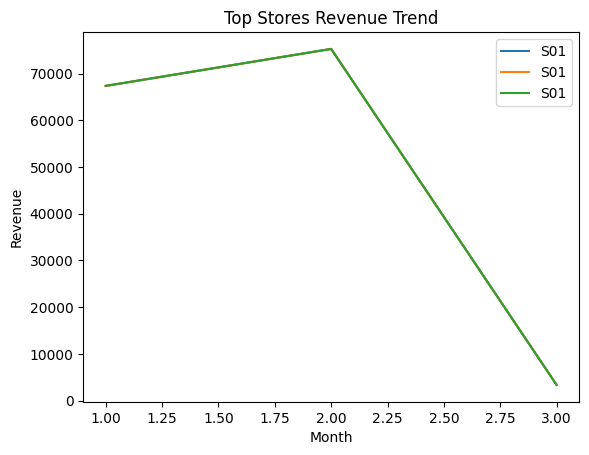

In [252]:
import matplotlib.pyplot as plt

top_stores = store_monthly.head(3)["store_id"]

for store in top_stores:
    subset = store_monthly[store_monthly["store_id"] == store]
    plt.plot(
        subset["order_month"],
        subset["net_order_value"],
        label=store
    )

plt.legend()
plt.title("Top Stores Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


In [253]:
# You can calculate CAGR per store:

store_growth = (
    store_monthly
    .groupby("store_id")["net_order_value"]
    .agg(["first", "last"])
)

store_growth["growth_percent"] = (
    (store_growth["last"] - store_growth["first"])
    / store_growth["first"]
)

In [254]:
store_growth.head()

,first,last,growth_percent
store_id,,,
S01,67380.0,3341.0,-0.950416
S02,76163.0,5081.0,-0.933288
S03,83449.0,2280.0,-0.972678
S04,99684.0,65774.0,-0.340175
S05,72227.0,68730.0,-0.048417


In [ ]:
# Q4. What is Average Order Value (AOV) trend?
aov_trend = (
    fact
    .groupby(["store_id", "order_year", "order_month"])
    .agg(
        total_revenue=("net_order_value", "sum"),
        total_orders=("order_id", "count")
    )
    .reset_index()
)

aov_trend["aov"] = (
    aov_trend["total_revenue"] / aov_trend["total_orders"]
)

aov_trend.head()


,store_id,order_year,order_month,total_revenue,total_orders,aov
0,S01,2024,1,67380.0,37,1821.081081
1,S01,2024,2,75302.0,37,2035.189189
2,S01,2024,3,3341.0,1,3341.000000
3,S02,2024,1,76163.0,37,2058.459459
4,S02,2024,2,61286.0,32,1915.187500


In [115]:


aov_monthly = (
    aov_trend
    .groupby(["store_id", "order_year", "order_month"])["aov"]
    .mean()
    .reset_index()
)

aov_monthly.head()

,store_id,order_year,order_month,aov
0,S01,2024,1,1821.081081
1,S01,2024,2,2035.189189
2,S01,2024,3,3341.000000
3,S02,2024,1,2058.459459
4,S02,2024,2,1915.187500


In [120]:
# Q5. What is overall delivery SLA compliance?

sla_compliance = (
    fact["delivered_within_20min"].mean()
)

sla_compliance

# anything else that we can do ?

sla_compliance_by_store = (
    fact
    .groupby("store_id")["delivered_within_20min"]
    .mean()
    .reset_index()
)  

sla_compliance_by_store.head()

,store_id,delivered_within_20min
0,S01,0.026667
1,S02,0.000000
2,S03,0.100000
3,S04,0.051948
4,S05,0.044118


In [126]:
fact.head()

,order_id,user_id,order_date,city_x,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,cancelled_flag,returned_flag,delivered_within_20min,delayed_flag,order_rank_for_user,is_first_order,is_repeat_order,user_total_orders,user_total_spend,user_avg_order_value
0,10503,U0001,2024-01-15 18:17:00,Bangalore,S12,NaN,Returned,Card,2024,1,...,0,1,0,0,1,1,0,1,2773.0,2773.000000
1,10990,U0002,2024-01-20 04:53:00,Hyderabad,S06,NaN,Cancelled,Card,2024,1,...,1,0,0,0,1,1,0,1,1230.0,1230.000000
2,11083,U0003,2024-02-12 17:34:00,Hyderabad,S07,NaN,Delivered,COD,2024,2,...,0,0,0,0,1,1,0,1,1405.0,1405.000000
3,10061,U0004,2024-01-24 10:32:00,Chennai,S13,14.0,Delivered,COD,2024,1,...,0,0,1,0,1,1,0,1,68.0,68.000000
4,10378,U0007,2024-01-25 17:25:00,Delhi,S09,NaN,Returned,Card,2024,1,...,0,1,0,0,1,1,0,3,9266.0,3088.666667


In [ ]:
# Q6. Revenue Contribution by Premium Users
premium_revenue = fact[fact["is_premium"]==1]["net_order_value"].sum()
premium_revenue

total_revenue = fact["net_order_value"].sum()
premium_percentage = (premium_revenue / total_revenue * 100)
print(f"The percentage of revenue that comes from premium users is: {premium_percentage:.2f}%")

The percentage of revenue that comes from premium users is: 48.17%


In [137]:
products.head(2)

,product_id,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent
0,P0001,Beverages,SubB,Unknown,461,406.64,54.36,0.12
1,P0002,Beverages,SubB,Unknown,400,316.93,83.07,0.21


In [ ]:
# Q7. What is category-wise revenue contribution?

category_revenue = (
    items_enriched
    .groupby("category")["net_revenue"]
    .sum()
    .reset_index()
    .sort_values("net_revenue", ascending=False)
)

category_revenue


,category,net_revenue
1,Grocery,842471.0
2,Personal Care,733324.0
3,Snacks,724354.0
0,Beverages,647253.0


In [162]:
fact.columns

Index(['order_id', 'user_id', 'order_date', 'city_x', 'store_id',
       'delivery_time_min', 'order_status', 'payment_type', 'order_year',
       'order_month', 'order_day', 'order_hour', 'order_week',
       'delivery_time_missing', 'total_items', 'gross_order_value',
       'net_order_value', 'total_cost', 'total_discount', 'order_margin',
       'margin_percentage', 'signup_date', 'city_y', 'referral_code',
       'is_premium', 'age', 'age_group', 'city', 'store_size_sqft',
       'opening_date', 'store_age_days', 'delivered_flag', 'cancelled_flag',
       'returned_flag', 'delivered_within_20min', 'delayed_flag',
       'order_rank_for_user', 'is_first_order', 'is_repeat_order',
       'user_total_orders', 'user_total_spend', 'user_avg_order_value'],
      dtype='object')

In [ ]:
# Q8. What is the impact of discounts on revenue?

discount_impact = (
    items_enriched
    .groupby("discount")["net_revenue"]
    .sum()
    .reset_index()
    .sort_values("discount")
)
discount_impact.head()

,discount,net_revenue
0,0.0,2004249.0
1,5.0,60263.0
2,6.0,62087.0
3,7.0,44626.0
4,8.0,56093.0


In [ ]:
#  Create Discount Percentage per Order

fact["discount_pct"] = (
    fact["total_discount"] / fact["gross_order_value"]
)

fact["discount_pct"] = fact["discount_pct"].fillna(0)
fact.head()

,order_id,user_id,order_date,city_x,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,returned_flag,delivered_within_20min,delayed_flag,order_rank_for_user,is_first_order,is_repeat_order,user_total_orders,user_total_spend,user_avg_order_value,discount_pct
0,10503,U0001,2024-01-15 18:17:00,Bangalore,S12,NaN,Returned,Card,2024,1,...,1,0,0,1,1,0,1,2773.0,2773.000000,0.016667
1,10990,U0002,2024-01-20 04:53:00,Hyderabad,S06,NaN,Cancelled,Card,2024,1,...,0,0,0,1,1,0,1,1230.0,1230.000000,0.011254
2,11083,U0003,2024-02-12 17:34:00,Hyderabad,S07,NaN,Delivered,COD,2024,2,...,0,0,0,1,1,0,1,1405.0,1405.000000,0.005662
3,10061,U0004,2024-01-24 10:32:00,Chennai,S13,14.0,Delivered,COD,2024,1,...,0,1,0,1,1,0,1,68.0,68.000000,0.000000
4,10378,U0007,2024-01-25 17:25:00,Delhi,S09,NaN,Returned,Card,2024,1,...,1,0,0,1,1,0,3,9266.0,3088.666667,0.004711


In [164]:
fact["discount_bucket"] = pd.cut(
    fact["discount_pct"],
    bins=[-0.01, 0, 0.05, 0.10, 0.20, 1],
    labels=["No Discount", "0-5%", "5-10%", "10-20%", "20%+"]
)


In [165]:
discount_impact = (
    fact
    .groupby("discount_bucket")
    .agg(
        avg_order_value=("net_order_value", "mean"),
        avg_margin=("order_margin", "mean"),
        total_orders=("order_id", "count")
    )
    .reset_index()
)

discount_impact


C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\1604870911.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("discount_bucket")


,discount_bucket,avg_order_value,avg_margin,total_orders
0,No Discount,1511.038168,392.563359,524
1,0-5%,2296.282353,549.137294,935
2,5-10%,317.347826,-211.502609,23
3,10-20%,93.916667,-476.827500,12
4,20%+,28.000000,-206.885000,6


In [ ]:
fact[["discount_pct", "net_order_value"]].corr()

""" Positive → higher discount = higher order value

Negative → discount not driving larger baskets"""


,discount_pct,net_order_value
discount_pct,1.000000,-0.202925
net_order_value,-0.202925,1.000000


In [167]:
fact[["discount_pct", "order_margin"]].corr()


,discount_pct,order_margin
discount_pct,1.000000,-0.144065
order_margin,-0.144065,1.000000


In [ ]:
# Revenue Lift vs No Discount
fact["discount_flag"] = (fact["total_discount"] > 0).astype(int)

fact.groupby("discount_flag").agg(
    avg_order_value=("net_order_value", "mean"),
    avg_margin=("order_margin", "mean"),
    total_orders=("order_id", "count")
)


,avg_order_value,avg_margin,total_orders
discount_flag,,,
0,1511.038168,392.563359,524
1,2208.625000,513.950379,976


In [174]:
# Revenue Contribution by Discount Level
discount_revenue = (
    fact
    .groupby("discount_bucket")["net_order_value"]
    .sum()
    .reset_index()
)

discount_revenue.head()

C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\3183797524.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("discount_bucket")["net_order_value"]


,discount_bucket,net_order_value
0,No Discount,791784.0
1,0-5%,2147024.0
2,5-10%,7299.0
3,10-20%,1127.0
4,20%+,168.0


In [172]:
discount_revenue["contribution_%"] = (
    discount_revenue["net_order_value"] /
    discount_revenue["net_order_value"].sum()
) * 100

discount_revenue

,discount_bucket,net_order_value,contribution_%
0,No Discount,791784.0,26.863794
1,0-5%,2147024.0,72.844627
2,5-10%,7299.0,0.247642
3,10-20%,1127.0,0.038237
4,20%+,168.0,0.005700


In [178]:
items_enriched.columns

Index(['product_id', 'qty', 'price', 'discount', 'order_id', 'net_revenue',
       'gross_revenue', 'category', 'subcategory', 'brand', 'mrp',
       'cost_price', 'gross_margin', 'margin_percent', 'total_cost'],
      dtype='object')

In [ ]:
# Q9. What are the top 10 revenue-generating products?
top_products = (
    items_enriched
    .groupby("product_id")["net_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_id
P0089    12974.0
P0109    12966.0
P0371    12515.0
P0340    11874.0
P0055    11827.0
P0111    11686.0
P0187    11662.0
P0171    11634.0
P0067    11391.0
P0044    11390.0
Name: net_revenue, dtype: float64

In [181]:
fact["order_month"].unique()

array([1, 2, 3], dtype=int32)

In [ ]:
# Q10. What is revenue growth month-over-month (MoM)?

monthly_revenue = (
    fact
    .groupby("order_month")["net_order_value"]
    .sum()
    .reset_index()
)

monthly_revenue["revenue_growth"] = monthly_revenue["net_order_value"].pct_change() * 100
monthly_revenue

,order_month,net_order_value,revenue_growth
0,1,1481625.0,NaN
1,2,1416225.0,-4.414072
2,3,49552.0,-96.501121


In [183]:
fact["order_month_1"] = fact["order_date"].dt.to_period("M") # 

monthly_revenue = (
    fact
    .groupby("order_month_1")["net_order_value"]
    .sum()
    .reset_index()
)

monthly_revenue["revenue_growth"] = monthly_revenue["net_order_value"].pct_change() * 100
monthly_revenue

,order_month_1,net_order_value,revenue_growth
0,2024-01,1481625.0,NaN
1,2024-02,1416225.0,-4.414072
2,2024-03,49552.0,-96.501121


In [184]:
monthly = fact.groupby(["order_year","order_month"])["net_order_value"].sum()
monthly.pct_change()


order_year  order_month
2024        1                   NaN
            2             -0.044141
            3             -0.965011
Name: net_order_value, dtype: float64

In [ ]:
# Q11. What is city-wise profitability?

city_profitability = (
    fact
    .groupby("city")
    .agg(
        total_revenue=("net_order_value", "sum"),
        total_cost=("total_cost", "sum")
    )
    .reset_index()
)

city_profitability["profit"] = city_profitability["total_revenue"] - city_profitability["total_cost"]

city_profitability["profit_margin"] = city_profitability["profit"] / city_profitability["total_revenue"]
city_profitability.sort_values("profit_margin", ascending=False)

,city,total_revenue,total_cost,profit,profit_margin
2,Delhi,435808.0,323888.39,111919.61,0.256809
3,Hyderabad,917985.0,690861.35,227123.65,0.247415
4,Mumbai,569042.0,432820.34,136221.66,0.239388
1,Chennai,427286.0,330500.59,96785.41,0.226512
0,Bangalore,597281.0,462012.56,135268.44,0.226474


In [ ]:
# Q12. Revenue Contribution by Premium Users
premium_revenue = fact[fact["is_premium"]==1]["net_order_value"].sum()
premium_revenue


rev_pct = fact.groupby("is_premium")["net_order_value"].sum()/ fact["net_order_value"].sum() * 100

print(f"The percentage of revenue that comes from premium users is: {rev_pct[1]:.2f}%")

The percentage of revenue that comes from premium users is: 48.17%


In [ ]:
# Q13. AOV BY city
aov_city = (
    fact
    .groupby("city")
    .agg(
        total_revenue=("net_order_value", "sum"),
        total_orders=("order_id", "count")
    )
    .reset_index()
)

aov_city["aov"] = aov_city["total_revenue"] / aov_city["total_orders"]
aov_city.sort_values("aov", ascending=False)

,city,total_revenue,total_orders,aov
2,Delhi,435808.0,208,2095.230769
3,Hyderabad,917985.0,460,1995.619565
0,Bangalore,597281.0,309,1932.948220
1,Chennai,427286.0,222,1924.711712
4,Mumbai,569042.0,301,1890.504983


In [ ]:
# Q14. Revenue by Hour (Peak Hours Analysis)
revenue_by_hour = (
    fact
    .groupby("order_hour")["net_order_value"]
    .sum().reset_index()
)
revenue_by_hour["revenue_pct"] = (
    revenue_by_hour["net_order_value"] / revenue_by_hour["net_order_value"].sum() * 100
)

revenue_by_hour.sort_values("net_order_value", ascending=False)

,order_hour,net_order_value,revenue_pct
7,7,164116.0,5.568158
4,4,162446.0,5.511498
11,11,153001.0,5.191046
3,3,143293.0,4.861671
10,10,133468.0,4.528327
15,15,130976.0,4.443778
13,13,129741.0,4.401877
19,19,124670.0,4.229827
6,6,123444.0,4.188231
8,8,121895.0,4.135676


In [ ]:
# Q15. Weekend vs Weekday Revenue

fact['is_weekend'] = (fact['order_date'].dt.dayofweek >= 5).astype(int) # 5 and 6 correspond to Saturday and Sunday

print(fact.groupby("is_weekend")["net_order_value"].sum())

fact.groupby("is_weekend")["net_order_value"].sum() / fact["net_order_value"].sum() * 100

is_weekend
0    2154694.0
1     792708.0
Name: net_order_value, dtype: float64


is_weekend
0    73.104856
1    26.895144
Name: net_order_value, dtype: float64

In [ ]:
# Q16. Monthly active users (MAU) trend

fact.groupby(["order_year", "order_month"])["user_id"].nunique().reset_index(name="monthly_active_users")

,order_year,order_month,monthly_active_users
0,2024,1,556
1,2024,2,549
2,2024,3,26


In [ ]:
# Q17. repeat purchase rate


# i want to create a flag for repeat purchase, so I will group by user_id and order the data by order_date, then I will create a new column called "is_repeat_purchase" which will be 1 if the user has made more than 1 purchase and 0 otherwise.

fact = fact.sort_values(["user_id", "order_date"])
fact["is_repeat_purchase"] = fact.groupby("user_id")["order_id"].transform(lambda x: x.duplicated(keep=False)).astype(int) # 

# duplicated 
fact.head(10)




,order_id,user_id,order_date,city_x,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,is_repeat_order,user_total_orders,user_total_spend,user_avg_order_value,discount_pct,discount_bucket,discount_flag,order_month_1,is_weekend,is_repeat_purchase
0,10503,U0001,2024-01-15 18:17:00,Bangalore,S12,NaN,Returned,Card,2024,1,...,0,1,2773.0,2773.000000,0.016667,0-5%,1,2024-01,0,0
1,10990,U0002,2024-01-20 04:53:00,Hyderabad,S06,NaN,Cancelled,Card,2024,1,...,0,1,1230.0,1230.000000,0.011254,0-5%,1,2024-01,1,0
2,11083,U0003,2024-02-12 17:34:00,Hyderabad,S07,NaN,Delivered,COD,2024,2,...,0,1,1405.0,1405.000000,0.005662,0-5%,1,2024-02,0,0
3,10061,U0004,2024-01-24 10:32:00,Chennai,S13,14.0,Delivered,COD,2024,1,...,0,1,68.0,68.000000,0.000000,No Discount,0,2024-01,0,0
4,10378,U0007,2024-01-25 17:25:00,Delhi,S09,NaN,Returned,Card,2024,1,...,0,3,9266.0,3088.666667,0.004711,0-5%,1,2024-01,0,0
5,11189,U0007,2024-02-05 02:05:00,Mumbai,S04,NaN,Cancelled,COD,2024,2,...,1,3,9266.0,3088.666667,0.009619,0-5%,1,2024-02,0,0
6,10456,U0007,2024-02-25 03:54:00,Mumbai,S09,21.0,Cancelled,COD,2024,2,...,1,3,9266.0,3088.666667,0.004469,0-5%,1,2024-02,1,0
7,11417,U0009,2024-01-15 08:01:00,Mumbai,S06,NaN,Cancelled,Card,2024,1,...,0,2,4147.0,2073.500000,0.000000,No Discount,0,2024-01,0,0
8,10845,U0009,2024-02-28 15:46:00,Bangalore,S19,NaN,Delivered,UPI,2024,2,...,1,2,4147.0,2073.500000,0.004586,0-5%,1,2024-02,0,0
9,10031,U0012,2024-01-24 16:12:00,Bangalore,S11,NaN,Cancelled,Card,2024,1,...,0,1,2267.0,2267.000000,0.007877,0-5%,1,2024-01,0,0


In [ ]:
# Deleting the is_repeat_purchase column as it is not needed for further analysis and modeling, and it was just created for the purpose of understanding repeat purchase behavior. We can always recreate this flag in the future if needed, but for now, we will drop it to keep our fact table clean and focused on the key metrics and features that are relevant for our analysis and modeling tasks.
fact = fact.drop(columns=["is_repeat_purchase"])

In [216]:
fact['order_month_1'].unique()

<PeriodArray>
['2024-01', '2024-02', '2024-03']
Length: 3, dtype: period[M]

In [ ]:
# Creating a customer type flag based on whether it is the first order or not
fact["customer_type"] = np.where(fact["is_first_order"] == 1, "New", "Repeat")

In [223]:
# repeat purchase rate

repeat_purchase_rate = (
    fact
    .groupby("customer_type")["order_id"]
    .count()
    .reset_index(name="order_count")
)
repeat_purchase_rate["purchase_rate"] = (
    repeat_purchase_rate["order_count"] / repeat_purchase_rate["order_count"].sum() * 100
)
repeat_purchase_rate

,customer_type,order_count,purchase_rate
0,New,856,57.066667
1,Repeat,644,42.933333


In [226]:
# Q18. First Order Revenue Contribution
first_order_revenue = fact[fact["is_first_order"] == 1]["net_order_value"].sum()

first_order_revenue_percentage = first_order_revenue/ fact["net_order_value"].sum() * 100
print(f'First Order Revenue Contribution: {first_order_revenue_percentage:.2f}%')

First Order Revenue Contribution: 57.05%


In [227]:
fact.groupby("customer_type")["net_order_value"].sum() / fact["net_order_value"].sum() * 100

customer_type
New       57.051804
Repeat    42.948196
Name: net_order_value, dtype: float64

In [ ]:
# Q19. What is customer churn rate?

# Churn rate is the percentage of customers who stop using a product or service over a specific period.
# how to calculate churn rate? We can calculate churn rate by identifying customers who have not made a purchase in the last 3 months and dividing that number by the total number of customers.

fact["last_order_date"] = fact.groupby("user_id")["order_date"].transform("max")

latest_date = fact["order_date"].max() # check the latest order date in the dataset to understand the reference point for calculating months since last order
fact["days_since_last_order"] = (
    (latest_date - fact["last_order_date"]).dt.days)

fact["churn_flag"] = (fact["days_since_last_order"] > 30).astype(int)

churn_rate = fact["churn_flag"].mean() * 100
print(f"Customer Churn Rate: {churn_rate:.2f}%")


# but dont you think so since we are using transform to calculate the last order date, it will give us the same last order date for all orders of a user, which is correct. 
# However, when we calculate the days since last order, it will be the same for all orders of that user, which may not accurately reflect the churn status for each individual order.
# its more of a % of churned orders (as above is on order level i.e 1 row per order)


# use Method 2 - By grouping on user_id

Customer Churn Rate: 25.27%


In [233]:
fact.head(10)

,order_id,user_id,order_date,city_x,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,user_avg_order_value,discount_pct,discount_bucket,discount_flag,order_month_1,is_weekend,customer_type,last_order_date,days_since_last_order,churn_flag
0,10503,U0001,2024-01-15 18:17:00,Bangalore,S12,NaN,Returned,Card,2024,1,...,2773.000000,0.016667,0-5%,1,2024-01,0,New,2024-01-15 18:17:00,46,1
1,10990,U0002,2024-01-20 04:53:00,Hyderabad,S06,NaN,Cancelled,Card,2024,1,...,1230.000000,0.011254,0-5%,1,2024-01,1,New,2024-01-20 04:53:00,41,1
2,11083,U0003,2024-02-12 17:34:00,Hyderabad,S07,NaN,Delivered,COD,2024,2,...,1405.000000,0.005662,0-5%,1,2024-02,0,New,2024-02-12 17:34:00,18,0
3,10061,U0004,2024-01-24 10:32:00,Chennai,S13,14.0,Delivered,COD,2024,1,...,68.000000,0.000000,No Discount,0,2024-01,0,New,2024-01-24 10:32:00,37,1
4,10378,U0007,2024-01-25 17:25:00,Delhi,S09,NaN,Returned,Card,2024,1,...,3088.666667,0.004711,0-5%,1,2024-01,0,New,2024-02-25 03:54:00,5,0
5,11189,U0007,2024-02-05 02:05:00,Mumbai,S04,NaN,Cancelled,COD,2024,2,...,3088.666667,0.009619,0-5%,1,2024-02,0,Repeat,2024-02-25 03:54:00,5,0
6,10456,U0007,2024-02-25 03:54:00,Mumbai,S09,21.0,Cancelled,COD,2024,2,...,3088.666667,0.004469,0-5%,1,2024-02,1,Repeat,2024-02-25 03:54:00,5,0
7,11417,U0009,2024-01-15 08:01:00,Mumbai,S06,NaN,Cancelled,Card,2024,1,...,2073.500000,0.000000,No Discount,0,2024-01,0,New,2024-02-28 15:46:00,2,0
8,10845,U0009,2024-02-28 15:46:00,Bangalore,S19,NaN,Delivered,UPI,2024,2,...,2073.500000,0.004586,0-5%,1,2024-02,0,Repeat,2024-02-28 15:46:00,2,0
9,10031,U0012,2024-01-24 16:12:00,Bangalore,S11,NaN,Cancelled,Card,2024,1,...,2267.000000,0.007877,0-5%,1,2024-01,0,New,2024-01-24 16:12:00,37,1


In [ ]:
customer_last_order = (
    fact
    .groupby("user_id")["order_date"]
    .max()
    .reset_index()
    .rename(columns={"order_date": "last_order_date"})
)

customer_last_order["days_since_last_order"] = (
    (latest_date - customer_last_order["last_order_date"]).dt.days)

customer_last_order["churn_flag"] = (customer_last_order["days_since_last_order"] > 30).astype(int)



,user_id,last_order_date,days_since_last_order,churn_flag
0,U0001,2024-01-15 18:17:00,46,1
1,U0002,2024-01-20 04:53:00,41,1
2,U0003,2024-02-12 17:34:00,18,0
3,U0004,2024-01-24 10:32:00,37,1
4,U0007,2024-02-25 03:54:00,5,0
5,U0009,2024-02-28 15:46:00,2,0
6,U0012,2024-01-24 16:12:00,37,1
7,U0013,2024-02-05 02:30:00,25,0
8,U0014,2024-02-11 09:54:00,19,0
9,U0015,2024-02-25 03:57:00,5,0


In [235]:
churn_rate = customer_last_order["churn_flag"].mean() * 100
print(f"Customer Churn Rate: {churn_rate:.2f}%")

Customer Churn Rate: 32.71%


In [236]:
fact.columns

Index(['order_id', 'user_id', 'order_date', 'city_x', 'store_id',
       'delivery_time_min', 'order_status', 'payment_type', 'order_year',
       'order_month', 'order_day', 'order_hour', 'order_week',
       'delivery_time_missing', 'total_items', 'gross_order_value',
       'net_order_value', 'total_cost', 'total_discount', 'order_margin',
       'margin_percentage', 'signup_date', 'city_y', 'referral_code',
       'is_premium', 'age', 'age_group', 'city', 'store_size_sqft',
       'opening_date', 'store_age_days', 'delivered_flag', 'cancelled_flag',
       'returned_flag', 'delivered_within_20min', 'delayed_flag',
       'order_rank_for_user', 'is_first_order', 'is_repeat_order',
       'user_total_orders', 'user_total_spend', 'user_avg_order_value',
       'discount_pct', 'discount_bucket', 'discount_flag', 'order_month_1',
       'is_weekend', 'customer_type', 'last_order_date',
       'days_since_last_order', 'churn_flag'],
      dtype='object')

In [ ]:
# Q20. What is cohort-based retention analysis?

fact["signup_month"] = fact["signup_date"].dt.to_period("M")

print(fact['signup_month'].unique())

fact['order_month_1'].unique()


<PeriodArray>
['2023-11', '2023-12', '2023-04', '2023-07', '2023-08', '2023-10', '2023-02',
 '2023-05', '2023-03', '2023-06', '2023-01', '2023-09', '2024-01']
Length: 13, dtype: period[M]


<PeriodArray>
['2024-01', '2024-02', '2024-03']
Length: 3, dtype: period[M]

In [242]:
# cohort is calculated from the month of first order
fact["cohort_month"] = fact.groupby("user_id")["order_date"].transform("min").dt.to_period("M")

fact['cohort_month'].unique()

<PeriodArray>
['2024-01', '2024-02', '2024-03']
Length: 3, dtype: period[M]

In [243]:
fact['order_month_1'].unique()

<PeriodArray>
['2024-01', '2024-02', '2024-03']
Length: 3, dtype: period[M]

In [ ]:
# calculate the cohort index, which represents the number of months since the customer's first order (cohort month). This will help us to analyze customer retention and behavior over time since their first purchase. The cohort index is calculated by taking the difference in years and months between the order month and the cohort month, and then combining those differences to get a single index value that indicates how many months have passed since the customer's first order.
fact["cohort_index"] = (
    (fact["order_month_1"].dt.year - fact["cohort_month"].dt.year) * 12 + # this part calculates the difference in years between the order month and the cohort month, and converts it to months by multiplying by 12.
    (fact["order_month_1"].dt.month - fact["cohort_month"].dt.month) # this part calculates the difference in months between the order month and the cohort month. By adding these two parts together, we get the total number of months since the customer's first order, which is represented by the cohort index.
)

# what does the above code do? The above code calculates the cohort index for each order, which represents the number of months since the customer's first order (cohort month). It does this by taking the difference in years and months between the order month and the cohort month, and then combining those differences to get a single index value that indicates how many months have passed since the customer's first order. This cohort index can be used for retention analysis to see how customer behavior changes over time since their first purchase.

In [245]:
fact.head(10)

,order_id,user_id,order_date,city_x,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,discount_flag,order_month_1,is_weekend,customer_type,last_order_date,days_since_last_order,churn_flag,signup_month,cohort_month,cohort_index
0,10503,U0001,2024-01-15 18:17:00,Bangalore,S12,NaN,Returned,Card,2024,1,...,1,2024-01,0,New,2024-01-15 18:17:00,46,1,2023-11,2024-01,0
1,10990,U0002,2024-01-20 04:53:00,Hyderabad,S06,NaN,Cancelled,Card,2024,1,...,1,2024-01,1,New,2024-01-20 04:53:00,41,1,2023-12,2024-01,0
2,11083,U0003,2024-02-12 17:34:00,Hyderabad,S07,NaN,Delivered,COD,2024,2,...,1,2024-02,0,New,2024-02-12 17:34:00,18,0,2023-04,2024-02,0
3,10061,U0004,2024-01-24 10:32:00,Chennai,S13,14.0,Delivered,COD,2024,1,...,0,2024-01,0,New,2024-01-24 10:32:00,37,1,2023-04,2024-01,0
4,10378,U0007,2024-01-25 17:25:00,Delhi,S09,NaN,Returned,Card,2024,1,...,1,2024-01,0,New,2024-02-25 03:54:00,5,0,2023-07,2024-01,0
5,11189,U0007,2024-02-05 02:05:00,Mumbai,S04,NaN,Cancelled,COD,2024,2,...,1,2024-02,0,Repeat,2024-02-25 03:54:00,5,0,2023-07,2024-01,1
6,10456,U0007,2024-02-25 03:54:00,Mumbai,S09,21.0,Cancelled,COD,2024,2,...,1,2024-02,1,Repeat,2024-02-25 03:54:00,5,0,2023-07,2024-01,1
7,11417,U0009,2024-01-15 08:01:00,Mumbai,S06,NaN,Cancelled,Card,2024,1,...,0,2024-01,0,New,2024-02-28 15:46:00,2,0,2023-08,2024-01,0
8,10845,U0009,2024-02-28 15:46:00,Bangalore,S19,NaN,Delivered,UPI,2024,2,...,1,2024-02,0,Repeat,2024-02-28 15:46:00,2,0,2023-08,2024-01,1
9,10031,U0012,2024-01-24 16:12:00,Bangalore,S11,NaN,Cancelled,Card,2024,1,...,1,2024-01,0,New,2024-01-24 16:12:00,37,1,2023-11,2024-01,0


In [ ]:
# Count Active Users per Cohort per Month

cohort_data = (
    fact
    .groupby(["cohort_month", "cohort_index"])["user_id"] # 
    .nunique()
    .reset_index(name="active_users")
)

cohort_data.head()

,cohort_month,cohort_index,active_users
0,2024-01,0,556
1,2024-01,1,260
2,2024-01,2,12
3,2024-02,0,289
4,2024-02,1,3


In [250]:
# Calculate Cohort Size (Month 0 Users)

cohort_sizes = (
    cohort_data[cohort_data["cohort_index"] == 0]
    [["cohort_month", "active_users"]]
    .rename(columns={"active_users": "cohort_size"})
)

cohort_sizes

,cohort_month,cohort_size
0,2024-01,556
3,2024-02,289
5,2024-03,11


In [251]:
cohort_data = cohort_data.merge(cohort_sizes, on="cohort_month", how="left")

cohort_data

,cohort_month,cohort_index,active_users,cohort_size
0,2024-01,0,556,556
1,2024-01,1,260,556
2,2024-01,2,12,556
3,2024-02,0,289,289
4,2024-02,1,3,289
5,2024-03,0,11,11


In [252]:
cohort_data["retention_rate"] = (
    cohort_data["active_users"] / cohort_data["cohort_size"] * 100  )

cohort_data.head()

,cohort_month,cohort_index,active_users,cohort_size,retention_rate
0,2024-01,0,556,556,100.000000
1,2024-01,1,260,556,46.762590
2,2024-01,2,12,556,2.158273
3,2024-02,0,289,289,100.000000
4,2024-02,1,3,289,1.038062


In [253]:
cohort_pivot = cohort_data.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="retention_rate"
)

cohort_pivot

cohort_index,0,1,2
cohort_month,,,
2024-01,100.0,46.762590,2.158273
2024-02,100.0,1.038062,NaN
2024-03,100.0,NaN,NaN


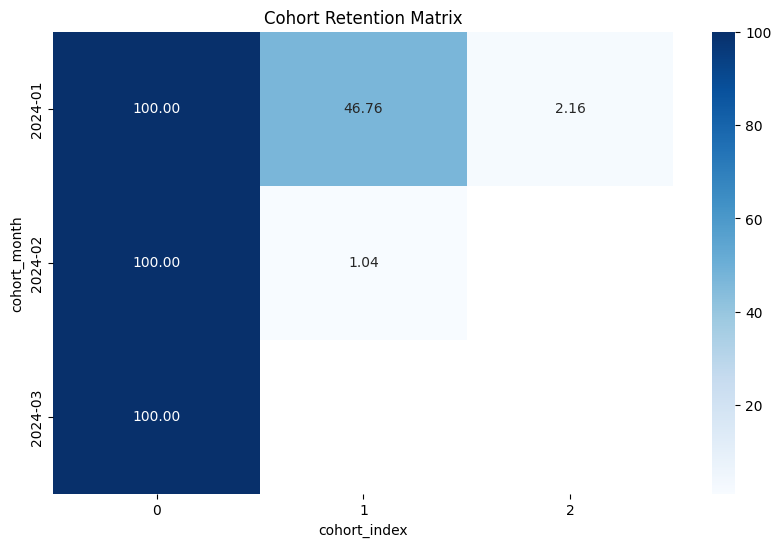

In [254]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(cohort_pivot, annot=True, fmt=".2f", cmap="Blues")
plt.title("Cohort Retention Matrix")
plt.show()

In [ ]:
# Q21. What is Customer Lifetime Value (proxy)?

# Customer Lifetime Value (CLV) is a prediction of the net profit attributed to the entire future relationship with a customer. It helps businesses understand the long-term value of their customers and make informed decisions about marketing, sales, and customer retention strategies.

# To calculate a proxy for Customer Lifetime Value (CLV), we can use the following formula:

# CLV = (Average Order Value) x (Purchase Frequency) x (Customer Lifespan)
# CLV = ARPU × Gross Margin × Lifetime

# but in our case we dont have the customer lifespan, so we can use a simplified version of CLV which is: 
fact.groupby("user_id")["net_order_value"].sum().mean()

# mean is used to get the average revenue per user, which is a proxy for Customer Lifetime Value (CLV) in this case, since we are not considering the customer lifespan or purchase frequency in our calculation. This gives us an estimate of how much revenue we can expect from an average customer over their lifetime with the business, based on their historical purchase behavior.


np.float64(3443.2266355140187)

In [259]:
# Margin-Based CLV (Recommended)
customer_clv = (
    fact
    .groupby("user_id")
    .agg(
        total_revenue=("net_order_value", "sum"),
        total_margin=("order_margin", "sum"),
        total_orders=("order_id", "count")
    )
    .reset_index()
)

customer_clv.head()

,user_id,total_revenue,total_margin,total_orders
0,U0001,2773.0,1780.51,1
1,U0002,1230.0,479.42,1
2,U0003,1405.0,844.78,1
3,U0004,68.0,-340.00,1
4,U0007,9266.0,3960.94,3


In [260]:
customer_clv["total_margin"].mean()

np.float64(826.3069742990655)

In [ ]:
# Q22. What is purchase frequency distribution?

# method 1
purchase_frequency = (
    fact
    .groupby("user_id")
    .size()
    .reset_index(name="purchase_frequency")
)

purchase_frequency.head()

,user_id,purchase_frequency
0,U0001,1
1,U0002,1
2,U0003,1
3,U0004,1
4,U0007,3


In [281]:
purchase_frequency["purchase_frequency"].value_counts()

purchase_frequency
1    440
2    258
3    106
4     39
5     10
7      2
6      1
Name: count, dtype: int64

In [ ]:
# Method 2 
purchase_fre_2 = fact['user_id'].value_counts().reset_index(name = 'orders_cnt')

purchase_fre_2

,user_id,orders_cnt
0,U0821,7
1,U0615,7
2,U0926,6
3,U0185,5
4,U1173,5
...,...,...
851,U1176,1
852,U1168,1
853,U0026,1
854,U0025,1


In [280]:
purchase_fre_2['orders_cnt'].value_counts()

orders_cnt
1    440
2    258
3    106
4     39
5     10
7      2
6      1
Name: count, dtype: int64

In [282]:
# Method 3

purchase_freq = (
    fact
    .groupby("user_id")["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "order_count"})
)

purchase_freq.head()

,user_id,order_count
0,U0001,1
1,U0002,1
2,U0003,1
3,U0004,1
4,U0007,3


In [283]:


frequency_distribution = (
    purchase_freq["order_count"]
    .value_counts()
    .sort_index().reset_index()
)

frequency_distribution.columns = ["orders_per_customer", "number_of_customers"]

frequency_distribution

,orders_per_customer,number_of_customers
0,1,440
1,2,258
2,3,106
3,4,39
4,5,10
5,6,1
6,7,2


In [273]:
purchase_freq.groupby('order_count').size()

order_count
1    440
2    258
3    106
4     39
5     10
6      1
7      2
dtype: int64

In [ ]:
# Q23. How does premium membership impact AOV?

# how to do it
fact.groupby("is_premium")["net_order_value"].mean().reset_index()


,is_premium,net_order_value
0,0,1986.544863
1,1,1942.201094


In [ ]:
# Q24. What is age-group spending behavior?

fact.groupby("age_group")["net_order_value"].mean()

C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\2911363332.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fact.groupby("age_group")["net_order_value"].mean()


age_group
18-25    2051.307692
26-35    2155.119048
36-50    1902.110553
50+      2059.325967
Name: net_order_value, dtype: float64

In [ ]:
# Q25. How do referral users perform vs non-referral users?

fact['referral_code'].unique()

array([nan, 'REF21', 'REF47', 'REF30', 'REF28', 'REF61', 'REF77', 'REF40',
       'REF55', 'REF17', 'REF10', 'REF94', 'REF11', 'REF14', 'REF15',
       'REF52', 'REF54', 'REF65', 'REF19', 'REF32', 'REF70', 'REF45',
       'REF59', 'REF13', 'REF16', 'REF83', 'REF23', 'REF95', 'REF37',
       'REF39', 'REF81', 'REF86', 'REF87', 'REF12', 'REF62', 'REF98',
       'REF73', 'REF66', 'REF41', 'REF79', 'REF22', 'REF68', 'REF51',
       'REF74', 'REF24', 'REF91', 'REF18', 'REF72', 'REF46', 'REF92',
       'REF75', 'REF57', 'REF97', 'REF76', 'REF49', 'REF26', 'REF67',
       'REF27', 'REF29', 'REF64', 'REF58', 'REF96', 'REF78', 'REF36',
       'REF50', 'REF80', 'REF34', 'REF44', 'REF60', 'REF43', 'REF93',
       'REF31', 'REF82', 'REF38', 'REF99', 'REF20', 'REF85', 'REF25',
       'REF71', 'REF53', 'REF48', 'REF56', 'REF88', 'REF63', 'REF89',
       'REF69', 'REF84', 'REF42', 'REF90', 'REF35'], dtype=object)

In [296]:
fact["referral_flag"] = (
    fact["referral_code"].notna()
).astype(int)

In [297]:
fact["referral_flag"].value_counts()

referral_flag
0    765
1    735
Name: count, dtype: int64

In [298]:
fact.groupby("referral_flag")["net_order_value"] \
    .mean() \
    .reset_index()

,referral_flag,net_order_value
0,0,1972.396078
1,1,1957.168707


In [ ]:
purchase_freq = (
    fact.groupby("user_id")["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "order_count"})
)

purchase_freq = purchase_freq.merge(
    fact[["user_id", "referral_flag"]].drop_duplicates(), # 
    on="user_id",
    how="left"
)

purchase_freq.groupby("referral_flag")["order_count"].mean()

referral_flag
0    1.746575
1    1.758373
Name: order_count, dtype: float64

In [300]:
purchase_freq

,user_id,order_count,referral_flag
0,U0001,1,0
1,U0002,1,1
2,U0003,1,0
3,U0004,1,0
4,U0007,3,1
...,...,...,...
851,U1191,1,1
852,U1192,2,0
853,U1193,1,0
854,U1194,1,0


In [ ]:
# Q26. What is RFM segmentation distribution?

analysis_date = fact["order_date"].max()

rfm = (
    fact.groupby("user_id")
    .agg(
        last_order_date=("order_date", "max"),
        frequency=("order_id", "count"),
        monetary=("order_margin", "sum")  # margin-based CLV proxy
    )
    .reset_index()
)

rfm["recency"] = (analysis_date - rfm["last_order_date"]).dt.days

rfm.head()

,user_id,last_order_date,frequency,monetary,recency
0,U0001,2024-01-15 18:17:00,1,1780.51,46
1,U0002,2024-01-20 04:53:00,1,479.42,41
2,U0003,2024-02-12 17:34:00,1,844.78,18
3,U0004,2024-01-24 10:32:00,1,-340.00,37
4,U0007,2024-02-25 03:54:00,3,3960.94,5


In [ ]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm

# Low recency = recently active = good

,user_id,last_order_date,frequency,monetary,recency,R_score
0,U0001,2024-01-15 18:17:00,1,1780.51,46,1
1,U0002,2024-01-20 04:53:00,1,479.42,41,2
2,U0003,2024-02-12 17:34:00,1,844.78,18,3
3,U0004,2024-01-24 10:32:00,1,-340.00,37,2
4,U0007,2024-02-25 03:54:00,3,3960.94,5,5
...,...,...,...,...,...,...
851,U1191,2024-01-15 07:37:00,1,348.51,46,1
852,U1192,2024-02-16 04:06:00,2,702.63,14,4
853,U1193,2024-02-04 08:11:00,1,2255.96,26,3
854,U1194,2024-01-22 03:02:00,1,254.43,39,2


In [303]:
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [304]:
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [305]:
rfm["RFM_segment"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,user_id,last_order_date,frequency,monetary,recency,R_score,M_score,F_score,RFM_segment
0,U0001,2024-01-15 18:17:00,1,1780.51,46,1,5,1,115
1,U0002,2024-01-20 04:53:00,1,479.42,41,2,3,1,213
2,U0003,2024-02-12 17:34:00,1,844.78,18,3,3,1,313
3,U0004,2024-01-24 10:32:00,1,-340.00,37,2,1,1,211
4,U0007,2024-02-25 03:54:00,3,3960.94,5,5,5,5,555


In [306]:
def segment_customer(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Champions"
    elif row["R_score"] >= 4:
        return "Loyal"
    elif row["F_score"] >= 4:
        return "Frequent"
    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "At Risk"
    else:
        return "Regular"

rfm["segment"] = rfm.apply(segment_customer, axis=1)

In [307]:
segment_distribution = (
    rfm["segment"]
    .value_counts(normalize=True) * 100
)

segment_distribution

segment
Champions    22.196262
Regular      20.210280
At Risk      20.093458
Loyal        19.742991
Frequent     17.757009
Name: proportion, dtype: float64

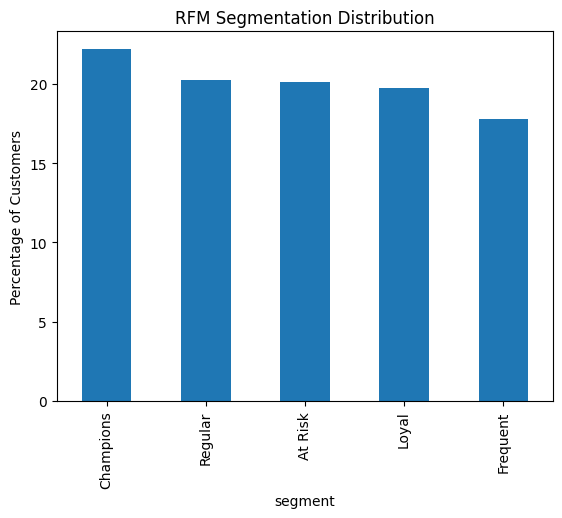

In [308]:
segment_distribution.plot(kind="bar")
plt.title("RFM Segmentation Distribution")
plt.ylabel("Percentage of Customers")
plt.show()

In [ ]:
# Q27. What is average delivery time by city?

fact.columns

Index(['order_id', 'user_id', 'order_date', 'city_x', 'store_id',
       'delivery_time_min', 'order_status', 'payment_type', 'order_year',
       'order_month', 'order_day', 'order_hour', 'order_week',
       'delivery_time_missing', 'total_items', 'gross_order_value',
       'net_order_value', 'total_cost', 'total_discount', 'order_margin',
       'margin_percentage', 'signup_date', 'city_y', 'referral_code',
       'is_premium', 'age', 'age_group', 'city', 'store_size_sqft',
       'opening_date', 'store_age_days', 'delivered_flag', 'cancelled_flag',
       'returned_flag', 'delivered_within_20min', 'delayed_flag',
       'order_rank_for_user', 'is_first_order', 'is_repeat_order',
       'user_total_orders', 'user_total_spend', 'user_avg_order_value',
       'discount_pct', 'discount_bucket', 'discount_flag', 'order_month_1',
       'is_weekend', 'customer_type', 'last_order_date',
       'days_since_last_order', 'churn_flag', 'signup_month', 'cohort_month',
       'cohort_index', '

In [311]:
fact.groupby("city")["delivery_time_min"].mean()


city
Bangalore    36.469799
Chennai      31.881356
Delhi        36.398058
Hyderabad    34.464844
Mumbai       35.155280
Name: delivery_time_min, dtype: float64

In [ ]:
# Q28. What percentage of orders are delivered within 20 minutes?
fact["delivered_within_20min"].mean() * 100


np.float64(4.0)

In [ ]:
# Q29. What is cancellation rate by city?

fact["cancelled_flag"].value_counts(normalize= True) * 100


cancelled_flag
0    65.066667
1    34.933333
Name: proportion, dtype: float64

In [318]:
fact.groupby("city")["cancelled_flag"].mean() * 100

city
Bangalore    31.715210
Chennai      35.135135
Delhi        35.096154
Hyderabad    38.043478
Mumbai       33.222591
Name: cancelled_flag, dtype: float64

In [ ]:
# Q30. What is return rate by category?

fact["returned_flag"].mean() * 100

np.float64(31.266666666666666)

In [327]:
products.head()

,product_id,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent
0,P0001,Beverages,SubB,Unknown,461,406.64,54.36,0.12
1,P0002,Beverages,SubB,Unknown,400,316.93,83.07,0.21
2,P0003,Grocery,SubB,BrandX,321,229.66,91.34,0.28
3,P0004,Snacks,SubA,Unknown,309,256.90,52.10,0.17
4,P0005,Beverages,SubC,Unknown,404,326.81,77.19,0.19


In [323]:
items_enriched.head()

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent,total_cost
0,P0352,4,211.0,0.0,10001,844.0,844.0,Beverages,SubA,Unknown,53,35.26,17.74,0.33,141.04
1,P0059,3,67.0,0.0,10002,201.0,201.0,Snacks,SubC,BrandY,127,90.00,37.00,0.29,270.00
2,P0163,2,441.0,0.0,10002,882.0,882.0,Snacks,SubB,BrandY,473,304.17,168.83,0.36,608.34
3,P0149,1,24.0,0.0,10002,24.0,24.0,Snacks,SubC,BrandX,101,75.87,25.13,0.25,75.87
4,P0334,4,273.0,0.0,10003,1092.0,1092.0,Personal Care,SubC,BrandZ,277,180.35,96.65,0.35,721.40


In [324]:
orders.head()

,order_id,user_id,order_date,city,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,order_day,order_hour,order_week,delivery_time_missing
0,10001,U0254,2024-01-03 08:47:00,Hyderabad,S05,NaN,Delivered,UPI,2024,1,3,8,1,True
1,10002,U0851,2024-01-05 16:46:00,Mumbai,S18,48.0,Delivered,Card,2024,1,5,16,1,False
2,10003,U0640,2024-02-07 12:12:00,Hyderabad,S17,57.0,Cancelled,COD,2024,2,7,12,6,False
3,10004,U0542,2024-01-30 06:06:00,Chennai,S16,NaN,Cancelled,UPI,2024,1,30,6,5,False
4,10005,U0571,2024-01-15 13:35:00,Bangalore,S18,42.0,Cancelled,UPI,2024,1,15,13,3,False


In [325]:
orders['order_status'].unique()

array(['Delivered', 'Cancelled', 'Returned'], dtype=object)

In [332]:
items_with_status = items_enriched.merge(
    orders[["order_id", "order_status"]],
    on="order_id",
    how="left"
)

items_with_status.head(15)

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent,total_cost,order_status
0,P0352,4,211.0,0.0,10001,844.0,844.0,Beverages,SubA,Unknown,53,35.26,17.74,0.33,141.04,Delivered
1,P0059,3,67.0,0.0,10002,201.0,201.0,Snacks,SubC,BrandY,127,90.00,37.00,0.29,270.00,Delivered
2,P0163,2,441.0,0.0,10002,882.0,882.0,Snacks,SubB,BrandY,473,304.17,168.83,0.36,608.34,Delivered
3,P0149,1,24.0,0.0,10002,24.0,24.0,Snacks,SubC,BrandX,101,75.87,25.13,0.25,75.87,Delivered
4,P0334,4,273.0,0.0,10003,1092.0,1092.0,Personal Care,SubC,BrandZ,277,180.35,96.65,0.35,721.40,Cancelled
5,P0027,3,119.0,0.0,10003,357.0,357.0,Snacks,SubA,BrandX,225,199.20,25.80,0.11,597.60,Cancelled
6,P0357,4,390.0,7.0,10003,1553.0,1560.0,Beverages,SubA,Unknown,262,188.57,73.43,0.28,754.28,Cancelled
7,P0299,1,125.0,0.0,10003,125.0,125.0,Personal Care,SubA,BrandX,160,104.21,55.79,0.35,104.21,Cancelled
8,P0222,4,137.0,0.0,10004,548.0,548.0,Grocery,SubA,BrandY,200,135.48,64.52,0.32,541.92,Cancelled
9,P0484,1,73.0,0.0,10004,73.0,73.0,Grocery,SubA,BrandY,92,71.72,20.28,0.22,71.72,Cancelled


In [331]:
items_with_status[items_with_status['order_status']=="Returned"]['order_status'].value_counts()

order_status
Returned    1396
Name: count, dtype: int64

In [333]:
items_with_status["return_flag"] = (
    items_with_status["order_status"] == "Returned"
).astype(int)

In [334]:
return_rate_category = (
    items_with_status
    .groupby("category")
    .agg(
        total_items=("product_id", "count"),
        returned_items=("return_flag", "sum")
    )
    .reset_index()
)

return_rate_category.head()

,category,total_items,returned_items
0,Beverages,1014,331
1,Grocery,1304,399
2,Personal Care,1139,350
3,Snacks,1058,316


In [337]:
return_rate_category['return_rate_cat'] = return_rate_category['returned_items'] / return_rate_category['total_items']  * 100

return_rate_category.head()

,category,total_items,returned_items,return_rate_cat
0,Beverages,1014,331,32.642998
1,Grocery,1304,399,30.598160
2,Personal Care,1139,350,30.728709
3,Snacks,1058,316,29.867675


In [340]:
# Reveue based returned Rate 
return_rate_category = (
    items_with_status
    .groupby("category")
    .agg(
        total_revenue=("net_revenue", "sum"),
        returned_revenue=("net_revenue",
                          lambda x: x[items_with_status.loc[x.index, "return_flag"] == 1].sum())
    )
    .reset_index()
)

return_rate_category["return_rate"] = (
    return_rate_category["returned_revenue"] /
    return_rate_category["total_revenue"] * 100
)

return_rate_category

,category,total_revenue,returned_revenue,return_rate
0,Beverages,647253.0,210416.0,32.509081
1,Grocery,842471.0,257862.0,30.607819
2,Personal Care,733324.0,203786.0,27.789354
3,Snacks,724354.0,212228.0,29.298934


In [ ]:
# Q31. What are peak ordering hours?

fact.groupby("order_hour")["order_id"].count()


order_hour
0     58
1     66
2     67
3     64
4     83
5     65
6     64
7     85
8     67
9     54
10    62
11    75
12    46
13    66
14    55
15    70
16    58
17    63
18    61
19    65
20    54
21    51
22    49
23    52
Name: order_id, dtype: int64

In [ ]:
# Q32. Does order size impact delivery time?

fact.columns

Index(['order_id', 'user_id', 'order_date', 'city_x', 'store_id',
       'delivery_time_min', 'order_status', 'payment_type', 'order_year',
       'order_month', 'order_day', 'order_hour', 'order_week',
       'delivery_time_missing', 'total_items', 'gross_order_value',
       'net_order_value', 'total_cost', 'total_discount', 'order_margin',
       'margin_percentage', 'signup_date', 'city_y', 'referral_code',
       'is_premium', 'age', 'age_group', 'city', 'store_size_sqft',
       'opening_date', 'store_age_days', 'delivered_flag', 'cancelled_flag',
       'returned_flag', 'delivered_within_20min', 'delayed_flag',
       'order_rank_for_user', 'is_first_order', 'is_repeat_order',
       'user_total_orders', 'user_total_spend', 'user_avg_order_value',
       'discount_pct', 'discount_bucket', 'discount_flag', 'order_month_1',
       'is_weekend', 'customer_type', 'last_order_date',
       'days_since_last_order', 'churn_flag', 'signup_month', 'cohort_month',
       'cohort_index', '

In [345]:
fact[["total_items", "delivery_time_min"]].corr()

,total_items,delivery_time_min
total_items,1.000000,0.025683
delivery_time_min,0.025683,1.000000


In [346]:
fact["order_size_bucket"] = pd.cut(
    fact["total_items"],
    bins=[0, 2, 5, 10, 20, 100],
    labels=["1-2", "3-5", "6-10", "11-20", "20+"]
)

In [347]:
# Average delivery time by Bucket

size_delivery = (
    fact
    .groupby("order_size_bucket")
    .agg(
        avg_delivery_time=("delivery_time_min", "mean"),
        total_orders=("order_id", "count")
    )
    .reset_index()
)

size_delivery

C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\2446873624.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("order_size_bucket")


,order_size_bucket,avg_delivery_time,total_orders
0,1-2,31.756757,159
1,3-5,35.923810,374
2,6-10,34.207120,581
3,11-20,35.896907,386
4,20+,NaN,0


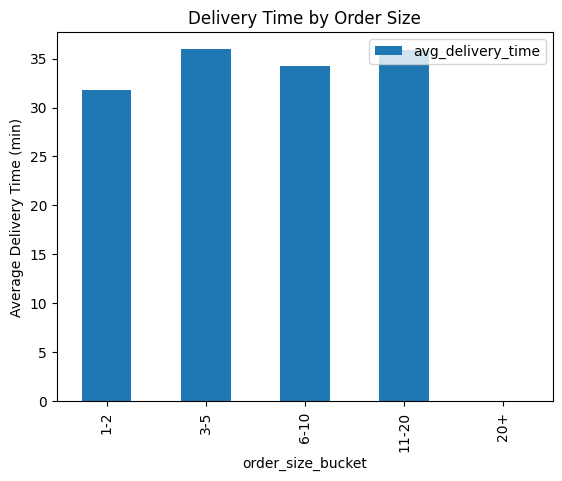

In [348]:
size_delivery.plot(
    x="order_size_bucket",
    y="avg_delivery_time",
    kind="bar"
)

plt.title("Delivery Time by Order Size")
plt.ylabel("Average Delivery Time (min)")
plt.show()

In [352]:
fact.groupby(["city", "order_size_bucket"])["delivery_time_min"].mean()

C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\791669124.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fact.groupby(["city", "order_size_bucket"])["delivery_time_min"].mean()


city       order_size_bucket
Bangalore  1-2                  31.944444
           3-5                  37.622222
           6-10                 35.591837
           11-20                38.432432
           20+                        NaN
Chennai    1-2                  39.900000
           3-5                  34.210526
           6-10                 31.272727
           11-20                26.423077
           20+                        NaN
Delhi      1-2                  28.333333
           3-5                  39.791667
           6-10                 33.457143
           11-20                39.085714
           20+                        NaN
Hyderabad  1-2                  29.652174
           3-5                  34.347826
           6-10                 35.000000
           11-20                35.508197
           20+                        NaN
Mumbai     1-2                  31.357143
           3-5                  36.058824
           6-10                 34.282051
     

In [ ]:
# Q33. Which stores have highest operational load?

fact.groupby("store_id")["order_id"].count().sort_values()


store_id
S12    58
S05    68
S20    68
S03    70
S10    71
S14    71
S08    71
S02    72
S18    72
S16    73
S11    74
S01    75
S04    77
S17    80
S19    80
S07    82
S09    83
S06    84
S13    85
S15    86
Name: order_id, dtype: int64

In [ ]:
# Q34. What is SLA compliance rate?

fact.groupby("store_id")["delivered_within_20min"].mean() * 100


store_id
S01     2.666667
S02     0.000000
S03    10.000000
S04     5.194805
S05     4.411765
S06     2.380952
S07     6.097561
S08     4.225352
S09     6.024096
S10     1.408451
S11     2.702703
S12     6.896552
S13     2.352941
S14     2.816901
S15     1.162791
S16     5.479452
S17     1.250000
S18     5.555556
S19     7.500000
S20     2.941176
Name: delivered_within_20min, dtype: float64

In [358]:
fact.columns

Index(['order_id', 'user_id', 'order_date', 'city_x', 'store_id',
       'delivery_time_min', 'order_status', 'payment_type', 'order_year',
       'order_month', 'order_day', 'order_hour', 'order_week',
       'delivery_time_missing', 'total_items', 'gross_order_value',
       'net_order_value', 'total_cost', 'total_discount', 'order_margin',
       'margin_percentage', 'signup_date', 'city_y', 'referral_code',
       'is_premium', 'age', 'age_group', 'city', 'store_size_sqft',
       'opening_date', 'store_age_days', 'delivered_flag', 'cancelled_flag',
       'returned_flag', 'delivered_within_20min', 'delayed_flag',
       'order_rank_for_user', 'is_first_order', 'is_repeat_order',
       'user_total_orders', 'user_total_spend', 'user_avg_order_value',
       'discount_pct', 'discount_bucket', 'discount_flag', 'order_month_1',
       'is_weekend', 'customer_type', 'last_order_date',
       'days_since_last_order', 'churn_flag', 'signup_month', 'cohort_month',
       'cohort_index', '

In [ ]:
# Q35. Are delayed deliveries increasing over time?

delivery_analysis = fact[
    (fact["delivered_flag"] == 1) &
    (fact["delivery_time_min"].notna())
].copy()

In [361]:
monthly_delay = (
    delivery_analysis
    .groupby(["order_year", "order_month"])
    .agg(
        total_delivered=("order_id", "count"),
        delayed_orders=("delayed_flag", "sum")
    )
    .reset_index()
)

monthly_delay["delay_rate"] = (
    monthly_delay["delayed_orders"] /
    monthly_delay["total_delivered"]
)

monthly_delay

,order_year,order_month,total_delivered,delayed_orders,delay_rate
0,2024,1,140,74,0.528571
1,2024,2,125,73,0.584000
2,2024,3,3,3,1.000000


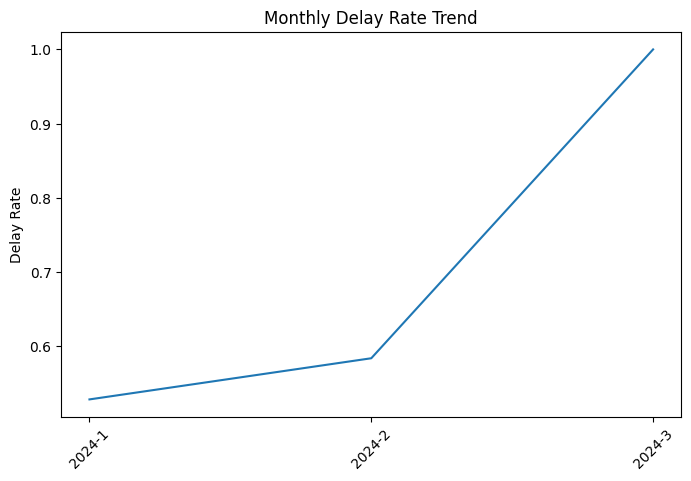

In [362]:


monthly_delay["year_month"] = (
    monthly_delay["order_year"].astype(str)
    + "-"
    + monthly_delay["order_month"].astype(str)
)

plt.figure(figsize=(8,5))
plt.plot(monthly_delay["year_month"], monthly_delay["delay_rate"])
plt.xticks(rotation=45)
plt.title("Monthly Delay Rate Trend")
plt.ylabel("Delay Rate")
plt.show()

In [ ]:
# Q36. What is operational efficiency index per store?                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
# Operational Efficiency Index=0.4×SLA_Rate+0.3×(1−Delay_Rate)+0.2×(1−Cancellation_Rate)+0.1×Normalized_Delivery_Speed

In [363]:
delivery_data = fact[
    (fact["delivery_time_min"].notna())
].copy()

In [364]:
store_ops = (
    delivery_data
    .groupby("store_id")
    .agg(
        sla_rate=("delivered_within_20min", "mean"),
        delay_rate=("delayed_flag", "mean"),
        cancellation_rate=("cancelled_flag", "mean"),
        avg_delivery_time=("delivery_time_min", "mean"),
        total_orders=("order_id", "count")
    )
    .reset_index()
)

store_ops.head()

,store_id,sla_rate,delay_rate,cancellation_rate,avg_delivery_time,total_orders
0,S01,0.048780,0.536585,0.463415,33.463415,41
1,S02,0.000000,0.605263,0.342105,35.631579,38
2,S03,0.175000,0.475000,0.300000,33.400000,40
3,S04,0.086957,0.695652,0.456522,37.521739,46
4,S05,0.075000,0.550000,0.350000,33.525000,40


In [365]:
store_ops["delivery_speed_score"] = (
    (store_ops["avg_delivery_time"].max() - store_ops["avg_delivery_time"]) /
    (store_ops["avg_delivery_time"].max() - store_ops["avg_delivery_time"].min())
)

In [366]:
store_ops.head()

,store_id,sla_rate,delay_rate,cancellation_rate,avg_delivery_time,total_orders,delivery_speed_score
0,S01,0.048780,0.536585,0.463415,33.463415,41,0.684487
1,S02,0.000000,0.605263,0.342105,35.631579,38,0.459959
2,S03,0.175000,0.475000,0.300000,33.400000,40,0.691055
3,S04,0.086957,0.695652,0.456522,37.521739,46,0.264219
4,S05,0.075000,0.550000,0.350000,33.525000,40,0.678110


In [367]:
store_ops["efficiency_index"] = (
    0.4 * store_ops["sla_rate"] +
    0.3 * (1 - store_ops["delay_rate"]) +
    0.2 * (1 - store_ops["cancellation_rate"]) +
    0.1 * store_ops["delivery_speed_score"]
)

In [368]:
store_ops.head()

,store_id,sla_rate,delay_rate,cancellation_rate,avg_delivery_time,total_orders,delivery_speed_score,efficiency_index
0,S01,0.048780,0.536585,0.463415,33.463415,41,0.684487,0.334302
1,S02,0.000000,0.605263,0.342105,35.631579,38,0.459959,0.295996
2,S03,0.175000,0.475000,0.300000,33.400000,40,0.691055,0.436605
3,S04,0.086957,0.695652,0.456522,37.521739,46,0.264219,0.261205
4,S05,0.075000,0.550000,0.350000,33.525000,40,0.678110,0.362811


In [369]:
store_ops = store_ops.sort_values(
    "efficiency_index",
    ascending=False
)

store_ops[["store_id", "efficiency_index"]]

,store_id,efficiency_index
18,S19,0.459146
2,S03,0.436605
13,S14,0.422222
15,S16,0.416354
6,S07,0.402827
8,S09,0.373307
12,S13,0.368526
4,S05,0.362811
10,S11,0.349003
0,S01,0.334302


In [ ]:
# Q37. Which categories generate highest margins?

items_enriched.groupby("category")["gross_margin"].mean()

category
Beverages        61.881716
Grocery          66.037469
Personal Care    62.485663
Snacks           71.883280
Name: gross_margin, dtype: float64

In [ ]:
# Q38. What is discount sensitivity by category?

items_enriched.head()

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent,total_cost
0,P0352,4,211.0,0.0,10001,844.0,844.0,Beverages,SubA,Unknown,53,35.26,17.74,0.33,141.04
1,P0059,3,67.0,0.0,10002,201.0,201.0,Snacks,SubC,BrandY,127,90.00,37.00,0.29,270.00
2,P0163,2,441.0,0.0,10002,882.0,882.0,Snacks,SubB,BrandY,473,304.17,168.83,0.36,608.34
3,P0149,1,24.0,0.0,10002,24.0,24.0,Snacks,SubC,BrandX,101,75.87,25.13,0.25,75.87
4,P0334,4,273.0,0.0,10003,1092.0,1092.0,Personal Care,SubC,BrandZ,277,180.35,96.65,0.35,721.40


In [376]:
items_enriched["discount_pct"] = (
    items_enriched["discount"] / items_enriched["price"]
).fillna(0)

In [ ]:
discount_sensitivity = (
    items_enriched
    .groupby("category")
    .apply(lambda x: x["discount_pct"].corr(x["net_revenue"]))
    .reset_index(name="discount_revenue_corr")
)

discount_sensitivity

# Negative correlation → Discount reduces revenue

C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\2762428158.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["discount_pct"].corr(x["net_revenue"]))


,category,discount_revenue_corr
0,Beverages,-0.276949
1,Grocery,-0.264250
2,Personal Care,-0.222682
3,Snacks,-0.214072


In [378]:
items_enriched["discount_bucket"] = pd.cut(
    items_enriched["discount_pct"],
    bins=[-0.01, 0, 0.05, 0.10, 0.20, 1],
    labels=["No Discount", "0-5%", "5-10%", "10-20%", "20%+"]
)

In [379]:
discount_analysis = (
    items_enriched
    .groupby(["category", "discount_bucket"])
    .agg(
        avg_revenue=("net_revenue", "mean"),
        total_quantity=("qty", "sum"),
        total_orders=("order_id", "count")
    )
    .reset_index()
)

discount_analysis

C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\2988538587.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["category", "discount_bucket"])


,category,discount_bucket,avg_revenue,total_quantity,total_orders
0,Beverages,No Discount,654.596850,1584,635
1,Beverages,0-5%,829.898936,437,188
2,Beverages,5-10%,605.653465,281,101
3,Beverages,10-20%,231.586957,116,46
4,Beverages,20%+,84.977273,97,44
5,Grocery,No Discount,677.065421,2153,856
6,Grocery,0-5%,848.436364,536,220
7,Grocery,5-10%,453.091603,289,131
8,Grocery,10-20%,234.072727,129,55
9,Grocery,20%+,95.666667,104,42


In [ ]:
# Q39. Which brands perform best in each city?

items_enriched.head()

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent,total_cost,discount_pct,discount_bucket
0,P0352,4,211.0,0.0,10001,844.0,844.0,Beverages,SubA,Unknown,53,35.26,17.74,0.33,141.04,0.0,No Discount
1,P0059,3,67.0,0.0,10002,201.0,201.0,Snacks,SubC,BrandY,127,90.00,37.00,0.29,270.00,0.0,No Discount
2,P0163,2,441.0,0.0,10002,882.0,882.0,Snacks,SubB,BrandY,473,304.17,168.83,0.36,608.34,0.0,No Discount
3,P0149,1,24.0,0.0,10002,24.0,24.0,Snacks,SubC,BrandX,101,75.87,25.13,0.25,75.87,0.0,No Discount
4,P0334,4,273.0,0.0,10003,1092.0,1092.0,Personal Care,SubC,BrandZ,277,180.35,96.65,0.35,721.40,0.0,No Discount


In [386]:
items_city = items_enriched.merge(
    fact[["order_id", "city"]],
    on="order_id",
    how="left"
)

items_city.head()

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent,total_cost,discount_pct,discount_bucket,city
0,P0352,4,211.0,0.0,10001,844.0,844.0,Beverages,SubA,Unknown,53,35.26,17.74,0.33,141.04,0.0,No Discount,Hyderabad
1,P0059,3,67.0,0.0,10002,201.0,201.0,Snacks,SubC,BrandY,127,90.00,37.00,0.29,270.00,0.0,No Discount,Mumbai
2,P0163,2,441.0,0.0,10002,882.0,882.0,Snacks,SubB,BrandY,473,304.17,168.83,0.36,608.34,0.0,No Discount,Mumbai
3,P0149,1,24.0,0.0,10002,24.0,24.0,Snacks,SubC,BrandX,101,75.87,25.13,0.25,75.87,0.0,No Discount,Mumbai
4,P0334,4,273.0,0.0,10003,1092.0,1092.0,Personal Care,SubC,BrandZ,277,180.35,96.65,0.35,721.40,0.0,No Discount,Hyderabad


In [384]:
stores.head()

,store_id,city,store_size_sqft,opening_date,store_age_days
0,S01,Hyderabad,1474,2023-03-15,1070
1,S02,Mumbai,2423,2023-12-13,797
2,S03,Hyderabad,4441,2023-08-20,912
3,S04,Delhi,1118,2023-05-09,1015
4,S05,Hyderabad,1249,2023-09-25,876


In [387]:
brand_city_perf = (
    items_city
    .groupby(["city", "brand"])
    .agg(
        total_revenue=("net_revenue", "sum"),
        total_quantity=("qty", "sum")
    )
    .reset_index()
)

brand_city_perf

,city,brand,total_revenue,total_quantity
0,Bangalore,BrandX,150480.0,568
1,Bangalore,BrandY,142207.0,531
2,Bangalore,BrandZ,132844.0,523
3,Bangalore,Unknown,171750.0,640
4,Chennai,BrandX,89569.0,335
5,Chennai,BrandY,95910.0,403
6,Chennai,BrandZ,112442.0,434
7,Chennai,Unknown,129365.0,458
8,Delhi,BrandX,99059.0,381
9,Delhi,BrandY,124471.0,481


In [389]:
brand_city_perf["rank"] = (
    brand_city_perf
    .groupby("city")["total_revenue"]
    .rank(method="first", ascending=False)
)

brand_city_perf


,city,brand,total_revenue,total_quantity,rank
0,Bangalore,BrandX,150480.0,568,2.0
1,Bangalore,BrandY,142207.0,531,3.0
2,Bangalore,BrandZ,132844.0,523,4.0
3,Bangalore,Unknown,171750.0,640,1.0
4,Chennai,BrandX,89569.0,335,4.0
5,Chennai,BrandY,95910.0,403,3.0
6,Chennai,BrandZ,112442.0,434,2.0
7,Chennai,Unknown,129365.0,458,1.0
8,Delhi,BrandX,99059.0,381,3.0
9,Delhi,BrandY,124471.0,481,1.0


In [ ]:
# Q40. What are fast vs slow-moving products?

product_perf = (
    items_enriched
    .groupby("product_id")
    .agg(
        total_quantity=("qty", "sum"),
        total_revenue=("net_revenue", "sum"),
        order_count=("order_id", "nunique")
    )
    .reset_index()
)

product_perf.head()

,product_id,total_quantity,total_revenue,order_count
0,P0001,12,1635.0,4
1,P0002,15,4244.0,6
2,P0003,30,8067.0,11
3,P0004,24,5473.0,11
4,P0005,20,4399.0,8


In [391]:
# We calculate how long the dataset spans:

total_days = (
    fact["order_date"].max() -
    fact["order_date"].min()
).days

In [392]:
product_perf["units_per_day"] = (
    product_perf["total_quantity"] / total_days
)

product_perf

,product_id,total_quantity,total_revenue,order_count,units_per_day
0,P0001,12,1635.0,4,0.200000
1,P0002,15,4244.0,6,0.250000
2,P0003,30,8067.0,11,0.500000
3,P0004,24,5473.0,11,0.400000
4,P0005,20,4399.0,8,0.333333
...,...,...,...,...,...
495,P0496,29,7252.0,9,0.483333
496,P0497,34,10853.0,12,0.566667
497,P0498,13,2226.0,5,0.216667
498,P0499,39,9673.0,15,0.650000


In [393]:
product_perf["movement_category"] = pd.qcut(
    product_perf["units_per_day"],
    q=3,
    labels=["Slow-Moving", "Medium-Moving", "Fast-Moving"]
)

In [394]:
product_perf["movement_category"].value_counts()

movement_category
Medium-Moving    172
Slow-Moving      171
Fast-Moving      157
Name: count, dtype: int64

In [395]:
product_perf.groupby("movement_category")["total_revenue"].sum()

C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\4031182019.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  product_perf.groupby("movement_category")["total_revenue"].sum()


movement_category
Slow-Moving       604238.0
Medium-Moving    1005501.0
Fast-Moving      1337663.0
Name: total_revenue, dtype: float64

In [ ]:
# Q41. Which products have highest return rates?

items_with_status.groupby("product_id")["return_flag"].sum()/items_with_status

product_id
P0001    1
P0002    3
P0003    4
P0004    2
P0005    4
        ..
P0496    3
P0497    3
P0498    0
P0499    2
P0500    3
Name: return_flag, Length: 500, dtype: int64

In [399]:
product_returns = (
    items_with_status
    .groupby("product_id")
    .agg(
        total_units=("qty", "sum"),
        returned_units=("qty",
                        lambda x: x[items_with_status.loc[x.index, "return_flag"] == 1].sum())
    )
    .reset_index()
)

product_returns["return_rate"] = (
    product_returns["returned_units"] /
    product_returns["total_units"]
)

product_returns.sort_values("return_rate", ascending=False).head(10)

,product_id,total_units,returned_units,return_rate
458,P0459,5,5,1.000000
196,P0197,3,3,1.000000
342,P0343,7,7,1.000000
103,P0104,7,6,0.857143
75,P0076,13,11,0.846154
450,P0451,12,10,0.833333
329,P0330,12,10,0.833333
466,P0467,15,12,0.800000
439,P0440,27,21,0.777778
78,P0079,16,12,0.750000


In [402]:
# Alternative — Order-Based Return Rate

product_returns = (
    items_with_status
    .groupby("product_id")
    .agg(
        total_orders=("order_id", "nunique"),
        returned_orders=("return_flag", "sum")
    )
    .reset_index()
)

product_returns["return_rate"] = (
    product_returns["returned_orders"] /
    product_returns["total_orders"]
)


product_returns

,product_id,total_orders,returned_orders,return_rate
0,P0001,4,1,0.250000
1,P0002,6,3,0.500000
2,P0003,11,4,0.363636
3,P0004,11,2,0.181818
4,P0005,8,4,0.500000
...,...,...,...,...
495,P0496,9,3,0.333333
496,P0497,12,3,0.250000
497,P0498,5,0,0.000000
498,P0499,15,2,0.133333


In [ ]:
# Q42. What is category growth trend?

items_city.head()

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent,total_cost,discount_pct,discount_bucket,city
0,P0352,4,211.0,0.0,10001,844.0,844.0,Beverages,SubA,Unknown,53,35.26,17.74,0.33,141.04,0.0,No Discount,Hyderabad
1,P0059,3,67.0,0.0,10002,201.0,201.0,Snacks,SubC,BrandY,127,90.00,37.00,0.29,270.00,0.0,No Discount,Mumbai
2,P0163,2,441.0,0.0,10002,882.0,882.0,Snacks,SubB,BrandY,473,304.17,168.83,0.36,608.34,0.0,No Discount,Mumbai
3,P0149,1,24.0,0.0,10002,24.0,24.0,Snacks,SubC,BrandX,101,75.87,25.13,0.25,75.87,0.0,No Discount,Mumbai
4,P0334,4,273.0,0.0,10003,1092.0,1092.0,Personal Care,SubC,BrandZ,277,180.35,96.65,0.35,721.40,0.0,No Discount,Hyderabad


In [406]:
items_enriched.head()

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent,total_cost,discount_pct,discount_bucket
0,P0352,4,211.0,0.0,10001,844.0,844.0,Beverages,SubA,Unknown,53,35.26,17.74,0.33,141.04,0.0,No Discount
1,P0059,3,67.0,0.0,10002,201.0,201.0,Snacks,SubC,BrandY,127,90.00,37.00,0.29,270.00,0.0,No Discount
2,P0163,2,441.0,0.0,10002,882.0,882.0,Snacks,SubB,BrandY,473,304.17,168.83,0.36,608.34,0.0,No Discount
3,P0149,1,24.0,0.0,10002,24.0,24.0,Snacks,SubC,BrandX,101,75.87,25.13,0.25,75.87,0.0,No Discount
4,P0334,4,273.0,0.0,10003,1092.0,1092.0,Personal Care,SubC,BrandZ,277,180.35,96.65,0.35,721.40,0.0,No Discount


In [409]:
items_enriched_month = items_enriched.merge(
    fact[["order_id", "order_date", "order_month_1"]],
    on="order_id",
    how="left"
)

items_enriched_month.head()

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent,total_cost,discount_pct,discount_bucket,order_date,order_month_1
0,P0352,4,211.0,0.0,10001,844.0,844.0,Beverages,SubA,Unknown,53,35.26,17.74,0.33,141.04,0.0,No Discount,2024-01-03 08:47:00,2024-01
1,P0059,3,67.0,0.0,10002,201.0,201.0,Snacks,SubC,BrandY,127,90.00,37.00,0.29,270.00,0.0,No Discount,2024-01-05 16:46:00,2024-01
2,P0163,2,441.0,0.0,10002,882.0,882.0,Snacks,SubB,BrandY,473,304.17,168.83,0.36,608.34,0.0,No Discount,2024-01-05 16:46:00,2024-01
3,P0149,1,24.0,0.0,10002,24.0,24.0,Snacks,SubC,BrandX,101,75.87,25.13,0.25,75.87,0.0,No Discount,2024-01-05 16:46:00,2024-01
4,P0334,4,273.0,0.0,10003,1092.0,1092.0,Personal Care,SubC,BrandZ,277,180.35,96.65,0.35,721.40,0.0,No Discount,2024-02-07 12:12:00,2024-02


In [416]:
category_monthly = (
    items_enriched_month
    .groupby(["category", "order_month_1"])
    .agg(
        monthly_revenue=("net_revenue", "sum"),
        monthly_quantity=("qty", "sum")
    )
    .reset_index()
)

category_monthly.head()

,category,order_month_1,monthly_revenue,monthly_quantity
0,Beverages,2024-01,332499.0,1300
1,Beverages,2024-02,302542.0,1165
2,Beverages,2024-03,12212.0,50
3,Grocery,2024-01,422762.0,1605
4,Grocery,2024-02,402143.0,1540


In [418]:
category_monthly["mom_growth"] = (
    category_monthly
    .groupby("category")["monthly_revenue"]
    .pct_change()
)

category_monthly

,category,order_month_1,monthly_revenue,monthly_quantity,mom_growth
0,Beverages,2024-01,332499.0,1300,NaN
1,Beverages,2024-02,302542.0,1165,-0.090097
2,Beverages,2024-03,12212.0,50,-0.959635
3,Grocery,2024-01,422762.0,1605,NaN
4,Grocery,2024-02,402143.0,1540,-0.048772
5,Grocery,2024-03,17566.0,66,-0.956319
6,Personal Care,2024-01,358445.0,1414,NaN
7,Personal Care,2024-02,361100.0,1405,0.007407
8,Personal Care,2024-03,13779.0,48,-0.961842
9,Snacks,2024-01,367919.0,1357,NaN


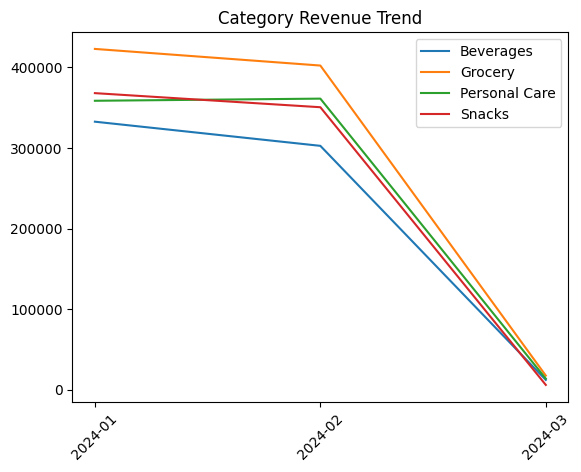

In [420]:


for cat in category_monthly["category"].unique():
    subset = category_monthly[
        category_monthly["category"] == cat
    ]
    
    plt.plot(
        subset["order_month_1"].astype(str),
        subset["monthly_revenue"],
        label=cat
    )

plt.legend()
plt.xticks(rotation=45)
plt.title("Category Revenue Trend")
plt.show()

In [ ]:
# Q43. What is contribution margin by subcategory?

items_enriched_month["item_margin"] = (
    items_enriched_month["qty"] *
    (items_enriched_month["price"] - items_enriched_month["discount"] - items_enriched_month["cost_price"])
)

In [423]:
items_enriched_month.head()

,product_id,qty,price,discount,order_id,net_revenue,gross_revenue,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent,total_cost,discount_pct,discount_bucket,order_date,order_month_1,item_margin
0,P0352,4,211.0,0.0,10001,844.0,844.0,Beverages,SubA,Unknown,53,35.26,17.74,0.33,141.04,0.0,No Discount,2024-01-03 08:47:00,2024-01,702.96
1,P0059,3,67.0,0.0,10002,201.0,201.0,Snacks,SubC,BrandY,127,90.00,37.00,0.29,270.00,0.0,No Discount,2024-01-05 16:46:00,2024-01,-69.00
2,P0163,2,441.0,0.0,10002,882.0,882.0,Snacks,SubB,BrandY,473,304.17,168.83,0.36,608.34,0.0,No Discount,2024-01-05 16:46:00,2024-01,273.66
3,P0149,1,24.0,0.0,10002,24.0,24.0,Snacks,SubC,BrandX,101,75.87,25.13,0.25,75.87,0.0,No Discount,2024-01-05 16:46:00,2024-01,-51.87
4,P0334,4,273.0,0.0,10003,1092.0,1092.0,Personal Care,SubC,BrandZ,277,180.35,96.65,0.35,721.40,0.0,No Discount,2024-02-07 12:12:00,2024-02,370.60


In [425]:
subcategory_margin = (
    items_enriched_month
    .groupby("subcategory")
    .agg(
        total_revenue=("net_revenue", "sum"),
        total_margin=("item_margin", "sum")
    )
    .reset_index()
)

subcategory_margin

,subcategory,total_revenue,total_margin
0,SubA,1079380.0,246640.67
1,SubB,946806.0,166292.25
2,SubC,921216.0,266756.85


In [426]:
subcategory_margin["contribution_margin_pct"] = (
    subcategory_margin["total_margin"] /
    subcategory_margin["total_revenue"]
)

subcategory_margin

,subcategory,total_revenue,total_margin,contribution_margin_pct
0,SubA,1079380.0,246640.67,0.228502
1,SubB,946806.0,166292.25,0.175635
2,SubC,921216.0,266756.85,0.289570


In [427]:
subcategory_margin.sort_values(
    "contribution_margin_pct",
    ascending=False
)

,subcategory,total_revenue,total_margin,contribution_margin_pct
2,SubC,921216.0,266756.85,0.289570
0,SubA,1079380.0,246640.67,0.228502
1,SubB,946806.0,166292.25,0.175635


In [ ]:
# Q44. What bundling opportunities exist?

basket = (
    items_enriched
    .groupby("order_id")["product_id"]
    .apply(list)
    .reset_index()
)

basket.head()

,order_id,product_id
0,10001,[P0352]
1,10002,"[P0059, P0163, P0149]"
2,10003,"[P0334, P0027, P0357, P0299]"
3,10004,"[P0222, P0484, P0050]"
4,10005,"[P0170, P0334, P0102]"


In [ ]:
# We generate all 2-product combinations per order.

from itertools import combinations
from collections import Counter

pair_counter = Counter()

for products in basket["product_id"]:
    unique_products = list(set(products))  # avoid duplicates
    pairs = combinations(unique_products, 2)
    pair_counter.update(pairs)

pair_df = (
    pd.DataFrame(pair_counter.items(), columns=["product_pair", "pair_count"])
    .sort_values("pair_count", ascending=False)
)

pair_df.head(10)

,product_pair,pair_count
497,"(P0478, P0482)",3
1273,"(P0195, P0237)",3
2440,"(P0255, P0361)",2
1192,"(P0304, P0338)",2
2122,"(P0019, P0405)",2
2332,"(P0383, P0393)",2
544,"(P0023, P0082)",2
84,"(P0308, P0279)",2
1734,"(P0165, P0281)",2
425,"(P0470, P0095)",2


In [ ]:
# Support = % of orders containing the pair.
total_orders = basket["order_id"].nunique()

pair_df["support"] = pair_df["pair_count"] / total_orders

In [445]:
products.head()

,product_id,category,subcategory,brand,mrp,cost_price,gross_margin,margin_percent
0,P0001,Beverages,SubB,Unknown,461,406.64,54.36,0.12
1,P0002,Beverages,SubB,Unknown,400,316.93,83.07,0.21
2,P0003,Grocery,SubB,BrandX,321,229.66,91.34,0.28
3,P0004,Snacks,SubA,Unknown,309,256.90,52.10,0.17
4,P0005,Beverages,SubC,Unknown,404,326.81,77.19,0.19


In [ ]:
# since product_name is not available we cannot do this 
pair_df[["product_1", "product_2"]] = pd.DataFrame(
    pair_df["product_pair"].tolist(),
    index=pair_df.index
)

pair_df = pair_df.merge(
    products[["product_id", "product_name"]],
    left_on="product_1",
    right_on="product_id",
    how="left"
).rename(columns={"product_name": "product_1_name"}).drop(columns=["product_id"])

pair_df = pair_df.merge(
    products[["product_id", "product_name"]],
    left_on="product_2",
    right_on="product_id",
    how="left"
).rename(columns={"product_name": "product_2_name"}).drop(columns=["product_id"])

KeyError: "['product_name'] not in index"

In [446]:
basket_cat = (
    items_enriched
    .groupby("order_id")["category"]
    .apply(lambda x: list(set(x)))
    .reset_index()
)

cat_counter = Counter()

for cats in basket_cat["category"]:
    pairs = combinations(cats, 2)
    cat_counter.update(pairs)

cat_pair_df = (
    pd.DataFrame(cat_counter.items(), columns=["category_pair", "pair_count"])
    .sort_values("pair_count", ascending=False)
)

cat_pair_df.head()

,category_pair,pair_count
3,"(Personal Care, Grocery)",466
4,"(Grocery, Snacks)",441
0,"(Personal Care, Snacks)",408
5,"(Grocery, Beverages)",405
1,"(Personal Care, Beverages)",381


In [ ]:
# Q45. Who are the top 20% customers contributing to 80% revenue?

customer_revenue = (
    fact
    .groupby("user_id")["net_order_value"]
    .sum()
    .reset_index()
    .rename(columns={"net_order_value": "total_revenue"})
)

In [448]:
customer_revenue = customer_revenue.sort_values(
    "total_revenue",
    ascending=False
).reset_index(drop=True)

customer_revenue

,user_id,total_revenue
0,U0615,18192.0
1,U0826,16535.0
2,U0452,15314.0
3,U1084,13839.0
4,U1106,13259.0
...,...,...
851,U1052,62.0
852,U1027,53.0
853,U0154,53.0
854,U1015,26.0


In [449]:
total_rev = customer_revenue["total_revenue"].sum()

customer_revenue["cumulative_revenue"] = (
    customer_revenue["total_revenue"].cumsum()
)

customer_revenue["cumulative_pct"] = (
    customer_revenue["cumulative_revenue"] / total_rev
)

In [450]:
customer_revenue

,user_id,total_revenue,cumulative_revenue,cumulative_pct
0,U0615,18192.0,18192.0,0.006172
1,U0826,16535.0,34727.0,0.011782
2,U0452,15314.0,50041.0,0.016978
3,U1084,13839.0,63880.0,0.021673
4,U1106,13259.0,77139.0,0.026172
...,...,...,...,...
851,U1052,62.0,2947268.0,0.999955
852,U1027,53.0,2947321.0,0.999973
853,U0154,53.0,2947374.0,0.999991
854,U1015,26.0,2947400.0,0.999999


In [451]:
top_customers = customer_revenue[
    customer_revenue["cumulative_pct"] <= 0.80
]

top_customers.head()

,user_id,total_revenue,cumulative_revenue,cumulative_pct
0,U0615,18192.0,18192.0,0.006172
1,U0826,16535.0,34727.0,0.011782
2,U0452,15314.0,50041.0,0.016978
3,U1084,13839.0,63880.0,0.021673
4,U1106,13259.0,77139.0,0.026172


In [ ]:
len(top_customers) / len(customer_revenue) # 52.92% of customers contribute to 80% of revenue 

0.5292056074766355

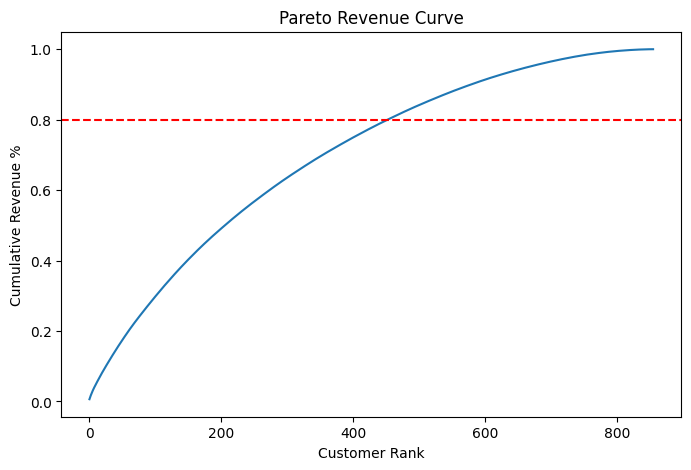

In [455]:
plt.figure(figsize=(8,5))
plt.plot(customer_revenue["cumulative_pct"])
plt.axhline(y=0.8, color="r", linestyle="--")
plt.title("Pareto Revenue Curve")
plt.ylabel("Cumulative Revenue %")
plt.xlabel("Customer Rank")
plt.show()

In [ ]:
# Q46. Can we forecast next month’s revenue?

monthly_revenue = (
    fact
    .groupby(["order_year", "order_month"])["net_order_value"]
    .sum()
    .reset_index()
)

monthly_revenue["year_month"] = pd.to_datetime(
    monthly_revenue["order_year"].astype(str) + "-" +
    monthly_revenue["order_month"].astype(str) + "-01"
)

monthly_revenue = monthly_revenue.sort_values("year_month")
monthly_revenue

,order_year,order_month,net_order_value,year_month
0,2024,1,1481625.0,2024-01-01
1,2024,2,1416225.0,2024-02-01
2,2024,3,49552.0,2024-03-01


In [458]:
# Simple Moving Average (Baseline Forecast)

monthly_revenue["rolling_avg_3"] = monthly_revenue['net_order_value'].rolling(3).mean()

monthly_revenue

,order_year,order_month,net_order_value,year_month,rolling_avg_3
0,2024,1,1481625.0,2024-01-01,NaN
1,2024,2,1416225.0,2024-02-01,NaN
2,2024,3,49552.0,2024-03-01,982467.333333


In [459]:
# Forecast next month

next_month_forecast = monthly_revenue["rolling_avg_3"].iloc[-1]
next_month_forecast

np.float64(982467.3333333334)

In [ ]:
# Q47. Does premium membership reduce churn?

fact.groupby("is_premium")["is_repeat_order"].mean()


is_premium
0    0.435631
1    0.422709
Name: is_repeat_order, dtype: float64

In [461]:
customer_last_order.head()

,user_id,last_order_date,days_since_last_order,churn_flag
0,U0001,2024-01-15 18:17:00,46,1
1,U0002,2024-01-20 04:53:00,41,1
2,U0003,2024-02-12 17:34:00,18,0
3,U0004,2024-01-24 10:32:00,37,1
4,U0007,2024-02-25 03:54:00,5,0


In [462]:
customer_churn = customer_last_order.merge(
    fact[["user_id", "is_premium"]].drop_duplicates(),
    on="user_id",
    how="left"
)

In [463]:
churn_comparison = (
    customer_churn
    .groupby("is_premium")["churn_flag"]
    .mean()
    .reset_index()
)

churn_comparison

,is_premium,churn_flag
0,0,0.329493
1,1,0.324645


In [465]:
churn_comparison["retention_rate"] = (
    1 - churn_comparison["churn_flag"]
)

churn_comparison

,is_premium,churn_flag,retention_rate
0,0,0.329493,0.670507
1,1,0.324645,0.675355


In [ ]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    customer_churn["is_premium"],
    customer_churn["churn_flag"]
)

chi2_contingency(contingency)

# since p value is greater than 0.05 we faile to reject the null hypothesis 

Chi2ContingencyResult(statistic=np.float64(0.006132064760878799), pvalue=np.float64(0.9375834506085832), dof=1, expected_freq=array([[292.03738318, 141.96261682],
       [283.96261682, 138.03738318]]))

In [ ]:
# Q48. What is store benchmarking score?

store_metrics = (
    fact
    .groupby("store_id")
    .agg(
        total_revenue=("net_order_value", "sum"),
        avg_order_value=("net_order_value", "mean"),
        total_orders=("order_id", "count"),
        sla_rate=("delivered_within_20min", "mean"),
        delay_rate=("delayed_flag", "mean"),
        cancellation_rate=("cancelled_flag", "mean"),
        avg_margin_pct=("margin_percentage", "mean")
    )
    .reset_index()
)

store_metrics.head()

,store_id,total_revenue,avg_order_value,total_orders,sla_rate,delay_rate,cancellation_rate,avg_margin_pct
0,S01,146023.0,1946.973333,75,0.026667,0.293333,0.480000,-0.155547
1,S02,142530.0,1979.583333,72,0.000000,0.319444,0.319444,0.050068
2,S03,142193.0,2031.328571,70,0.100000,0.271429,0.328571,0.112945
3,S04,165458.0,2148.805195,77,0.051948,0.415584,0.428571,0.069662
4,S05,140957.0,2072.897059,68,0.044118,0.323529,0.367647,0.074111


In [469]:
# Normalize metrics

def min_max(series):
    return (series - series.min()) / (series.max() - series.min())

store_metrics["rev_score"] = min_max(store_metrics["total_revenue"])
store_metrics["aov_score"] = min_max(store_metrics["avg_order_value"])
store_metrics["sla_score"] = min_max(store_metrics["sla_rate"])
store_metrics["margin_score"] = min_max(store_metrics["avg_margin_pct"])

In [470]:
# for negative metrics lower is better, for positive metrics higher is better

store_metrics["delay_score"] = 1 - min_max(store_metrics["delay_rate"])
store_metrics["cancel_score"] = 1 - min_max(store_metrics["cancellation_rate"])

In [471]:
store_metrics["benchmark_score"] = (
    0.30 * store_metrics["rev_score"] +
    0.25 * store_metrics["sla_score"] +
    0.20 * store_metrics["margin_score"] +
    0.10 * store_metrics["aov_score"] +
    0.10 * store_metrics["delay_score"] +
    0.05 * store_metrics["cancel_score"]
)

In [472]:
store_metrics = store_metrics.sort_values(
    "benchmark_score",
    ascending=False
)

store_metrics[["store_id", "benchmark_score"]]

,store_id,benchmark_score
6,S07,0.790328
8,S09,0.782808
2,S03,0.745450
15,S16,0.736854
3,S04,0.670081
14,S15,0.646062
18,S19,0.612767
7,S08,0.571959
4,S05,0.561014
11,S12,0.517122


In [ ]:
# Q49. What is profitability per delivery minute?

delivery_profit = fact[
    (fact["delivered_flag"] == 1) &
    (fact["delivery_time_min"] > 0) &
    (fact["order_margin"].notna())
].copy()

In [474]:
delivery_profit["profit_per_minute"] = (
    delivery_profit["order_margin"] /
    delivery_profit["delivery_time_min"]
)

delivery_profit.head()

,order_id,user_id,order_date,city_x,store_id,delivery_time_min,order_status,payment_type,order_year,order_month,...,customer_type,last_order_date,days_since_last_order,churn_flag,signup_month,cohort_month,cohort_index,referral_flag,order_size_bucket,profit_per_minute
3,10061,U0004,2024-01-24 10:32:00,Chennai,S13,14.0,Delivered,COD,2024,1,...,New,2024-01-24 10:32:00,37,1,2023-04,2024-01,0,0,1-2,-24.285714
11,10209,U0014,2024-02-07 10:55:00,Mumbai,S12,47.0,Delivered,Card,2024,2,...,New,2024-02-11 09:54:00,19,0,2023-10,2024-02,0,1,3-5,26.103830
20,10588,U0022,2024-02-04 02:29:00,Delhi,S04,15.0,Delivered,COD,2024,2,...,New,2024-02-04 02:29:00,26,0,2023-10,2024-02,0,1,11-20,60.250667
24,11168,U0028,2024-02-21 08:02:00,Bangalore,S16,17.0,Delivered,Card,2024,2,...,Repeat,2024-02-21 08:02:00,9,0,2023-02,2024-02,0,1,6-10,83.689412
25,10594,U0029,2024-01-11 05:04:00,Mumbai,S16,47.0,Delivered,Card,2024,1,...,New,2024-01-19 15:28:00,42,1,2023-12,2024-01,0,1,11-20,42.342766


In [ ]:
delivery_profit["profit_per_minute"].mean()

# overall profitability per minute

np.float64(17.830683428877705)

In [476]:
# store level profitability efficiency

store_profit_efficiency = (
    delivery_profit
    .groupby("store_id")
    .agg(
        avg_profit_per_min=("profit_per_minute", "mean"),
        avg_delivery_time=("delivery_time_min", "mean"),
        avg_margin=("order_margin", "mean"),
        total_orders=("order_id", "count")
    )
    .reset_index()
)

store_profit_efficiency.sort_values(
    "avg_profit_per_min",
    ascending=False
)

,store_id,avg_profit_per_min,avg_delivery_time,avg_margin,total_orders
15,S16,51.221080,31.384615,1422.886923,13
5,S06,35.354948,31.100000,981.871000,10
3,S04,32.642380,32.090909,706.899091,11
14,S15,24.894298,46.250000,714.477500,12
7,S08,21.921063,33.750000,546.310000,12
10,S11,20.880223,37.545455,686.676364,11
13,S14,19.281447,28.083333,460.834167,12
16,S17,18.813794,37.583333,726.915000,12
6,S07,17.912099,34.857143,543.277143,21
19,S20,17.394612,36.142857,617.562143,14


In [478]:
# city level efficiency

delivery_profit.groupby("city")["profit_per_minute"].mean()

city
Bangalore    24.142883
Chennai      16.712802
Delhi        29.859699
Hyderabad    13.145951
Mumbai       13.314028
Name: profit_per_minute, dtype: float64

In [ ]:
# does profitability decrease with delivery time

delivery_profit[["delivery_time_min", "profit_per_minute"]].corr()

# If negative correlation: Longer deliveries reduce profitability

,delivery_time_min,profit_per_minute
delivery_time_min,1.00000,-0.16037
profit_per_minute,-0.16037,1.00000


In [ ]:
# Q50. Which city has highest customer acquisition efficiency?

# it is Average revenue per new customer

first_order = (
    fact
    .groupby("user_id")
    .agg(
        first_order_date=("order_date", "min"),
        first_city=("city", "first")
    )
    .reset_index()
)

first_order.head()

,user_id,first_order_date,first_city
0,U0001,2024-01-15 18:17:00,Delhi
1,U0002,2024-01-20 04:53:00,Bangalore
2,U0003,2024-02-12 17:34:00,Hyderabad
3,U0004,2024-01-24 10:32:00,Hyderabad
4,U0007,2024-01-25 17:25:00,Mumbai


In [482]:
new_customers_city = (
    first_order
    .groupby("first_city")
    .agg(
        new_customers=("user_id", "count")
    )
    .reset_index()

)


new_customers_city

,first_city,new_customers
0,Bangalore,184
1,Chennai,138
2,Delhi,122
3,Hyderabad,241
4,Mumbai,171


In [483]:
# revenue from new customers

fact_with_first = fact.merge(
    first_order[["user_id", "first_city"]],
    on="user_id",
    how="left"
)

In [484]:
revenue_new_customers = (
    fact_with_first
    .groupby("first_city")["net_order_value"]
    .sum()
    .reset_index()
    .rename(columns={"net_order_value": "total_revenue"})
)

In [485]:
acq_efficiency = new_customers_city.merge(
    revenue_new_customers,
    on="first_city"
)

acq_efficiency["revenue_per_new_customer"] = (
    acq_efficiency["total_revenue"] /
    acq_efficiency["new_customers"]
)

acq_efficiency.sort_values(
    "revenue_per_new_customer",
    ascending=False
)


acq_efficiency

,first_city,new_customers,total_revenue,revenue_per_new_customer
0,Bangalore,184,640082.0,3478.706522
1,Chennai,138,445015.0,3224.746377
2,Delhi,122,496740.0,4071.639344
3,Hyderabad,241,817175.0,3390.767635
4,Mumbai,171,548390.0,3206.959064


In [488]:
# revenue generated within first 30 days of acquisition

fact_with_first["days_since_first"] = (
    fact_with_first["order_date"] -
    fact_with_first.groupby("user_id")["order_date"].transform("min")
).dt.days

first_30_day_revenue = (
    fact_with_first[
        fact_with_first["days_since_first"] <= 30
    ]
    .groupby("first_city")["net_order_value"]
    .sum()
    .reset_index()
)


first_30_day_revenue

,first_city,net_order_value
0,Bangalore,530740.0
1,Chennai,403157.0
2,Delhi,414391.0
3,Hyderabad,704532.0
4,Mumbai,477970.0


In [ ]:
# Q51. Which combination of factors drives highest order margin?

""" possible drivers 
is_premium

referral_flag

store_city

total_items

discount_amount

delivery_time_min

category (via items)

order_size_bucket

delayed_flag """

In [489]:
# order size bucket

fact["order_size_bucket"] = pd.qcut(
    fact["total_items"],
    3,
    labels=["Small", "Medium", "Large"]
)

In [494]:
fact.columns

Index(['order_id', 'user_id', 'order_date', 'city_x', 'store_id',
       'delivery_time_min', 'order_status', 'payment_type', 'order_year',
       'order_month', 'order_day', 'order_hour', 'order_week',
       'delivery_time_missing', 'total_items', 'gross_order_value',
       'net_order_value', 'total_cost', 'total_discount', 'order_margin',
       'margin_percentage', 'signup_date', 'city_y', 'referral_code',
       'is_premium', 'age', 'age_group', 'city', 'store_size_sqft',
       'opening_date', 'store_age_days', 'delivered_flag', 'cancelled_flag',
       'returned_flag', 'delivered_within_20min', 'delayed_flag',
       'order_rank_for_user', 'is_first_order', 'is_repeat_order',
       'user_total_orders', 'user_total_spend', 'user_avg_order_value',
       'discount_pct', 'discount_bucket', 'discount_flag', 'order_month_1',
       'is_weekend', 'customer_type', 'last_order_date',
       'days_since_last_order', 'churn_flag', 'signup_month', 'cohort_month',
       'cohort_index', '

In [ ]:
# delivery speed bucket

fact["delivery_bucket"] = pd.qcut(
    fact["delivery_time_min"],
    3,
    labels=["Fast", "Moderate", "Slow"]
)

In [499]:
fact.columns

Index(['order_id', 'user_id', 'order_date', 'city_x', 'store_id',
       'delivery_time_min', 'order_status', 'payment_type', 'order_year',
       'order_month', 'order_day', 'order_hour', 'order_week',
       'delivery_time_missing', 'total_items', 'gross_order_value',
       'net_order_value', 'total_cost', 'total_discount', 'order_margin',
       'margin_percentage', 'signup_date', 'city_y', 'referral_code',
       'is_premium', 'age', 'age_group', 'city', 'store_size_sqft',
       'opening_date', 'store_age_days', 'delivered_flag', 'cancelled_flag',
       'returned_flag', 'delivered_within_20min', 'delayed_flag',
       'order_rank_for_user', 'is_first_order', 'is_repeat_order',
       'user_total_orders', 'user_total_spend', 'user_avg_order_value',
       'discount_pct', 'discount_bucket', 'discount_flag', 'order_month_1',
       'is_weekend', 'customer_type', 'last_order_date',
       'days_since_last_order', 'churn_flag', 'signup_month', 'cohort_month',
       'cohort_index', '

In [501]:
print(fact.groupby("is_premium")["order_margin"].mean())
print(fact.groupby("order_size_bucket")["order_margin"].mean())
print(fact.groupby("discount_bucket")["order_margin"].mean())
print(fact.groupby("delivery_bucket")["order_margin"].mean())

is_premium
0    500.311834
1    441.284501
Name: order_margin, dtype: float64
order_size_bucket
Small     182.537974
Medium    496.398868
Large     761.721980
Name: order_margin, dtype: float64
discount_bucket
No Discount    392.563359
0-5%           549.137294
5-10%         -211.502609
10-20%        -476.827500
20%+          -206.885000
Name: order_margin, dtype: float64
delivery_bucket
Fast        461.684556
Moderate    407.916875
Slow        497.112107
Name: order_margin, dtype: float64


C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\352595059.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(fact.groupby("order_size_bucket")["order_margin"].mean())
C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\352595059.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(fact.groupby("discount_bucket")["order_margin"].mean())
C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\352595059.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

In [503]:
# Combination Analysis

margin_combo = (
    fact
    .groupby(["is_premium",
              "order_size_bucket",
              "discount_bucket"])
    .agg(
        avg_margin=("order_margin", "mean"),
        order_count=("order_id", "count")
    )
    .reset_index()
)


margin_combo

C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\2035718314.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["is_premium",


,is_premium,order_size_bucket,discount_bucket,avg_margin,order_count
0,0,Small,No Discount,247.700318,157
1,0,Small,0-5%,217.000619,97
2,0,Small,5-10%,-194.495000,8
3,0,Small,10-20%,-387.198333,6
4,0,Small,20%+,-99.480000,3
5,0,Medium,No Discount,563.594058,69
6,0,Medium,0-5%,580.943369,187
7,0,Medium,5-10%,-1395.200000,1
8,0,Medium,10-20%,NaN,0
9,0,Medium,20%+,NaN,0


In [504]:
margin_combo = margin_combo[
    margin_combo["order_count"] > 30
]

In [505]:
margin_combo.sort_values(
    "avg_margin",
    ascending=False
)

,is_premium,order_size_bucket,discount_bucket,avg_margin,order_count
10,0,Large,No Discount,932.114000,40
26,1,Large,0-5%,781.329268,205
11,0,Large,0-5%,724.207065,201
25,1,Large,No Discount,686.842955,44
6,0,Medium,0-5%,580.943369,187
5,0,Medium,No Discount,563.594058,69
20,1,Medium,No Discount,506.112740,73
21,1,Medium,0-5%,378.682552,145
0,0,Small,No Discount,247.700318,157
16,1,Small,0-5%,231.108100,100


In [507]:
margin_combo_city = (
    fact
    .groupby(["city",
              "is_premium",
              "order_size_bucket"])
    ["order_margin"]
    .mean()
    .reset_index()
)

margin_combo_city

C:\Users\zaids\AppData\Local\Temp\ipykernel_32356\1077115224.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["city",


,city,is_premium,order_size_bucket,order_margin
0,Bangalore,0,Small,184.138333
1,Bangalore,0,Medium,563.332881
2,Bangalore,0,Large,842.115532
3,Bangalore,1,Small,87.228947
4,Bangalore,1,Medium,238.474000
5,Bangalore,1,Large,802.023043
6,Chennai,0,Small,74.518696
7,Chennai,0,Medium,724.741290
8,Chennai,0,Large,612.017073
9,Chennai,1,Small,171.245349
